In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Notebook-A1.4 — fused-silica vortex validation
lambda0               = 800.0 nm
photon energy          = 1.550 eV
critical density rho_c = 1.742e+21 cm^-3

Material summary:


,material,n0,n2_m2_W,Ui_eV,K,beta_K_SI,Pcr_Gaussian_MW,Pcr_vortex_proxy_MW
0,fused_silica,1.4533,3.200000e-20,9.0,6,8.400000e-85,2.076582,7.683352



Reference beam settings:
tau_FWHM       = 65.0 fs
f_lens         = 15.0 mm
Vortex w0      = 0.060 mm
m_charge       = 1

Numerical grid:
Nx, Ny, Nt       = 192, 192, 256
dx, dy           = 3.125, 3.125 um
dt               = 0.703 fs
T_window         = 180.0 fs
z_max            = 18.0 mm
dz               = 100.0 um
estimated λ_min  = 276.1 nm
3D complex field memory ≈ 0.14 GB

Running fused-silica vortex m=1 validation scan
Running fused_silica | vortex_m1 | energy =   900.0 nJ | P_est =  13.85 MW
  initial center |E| max = 0.000e+00
Running fused_silica | vortex_m1 | energy =  1000.0 nJ | P_est =  15.38 MW
  initial center |E| max = 0.000e+00
Running fused_silica | vortex_m1 | energy =  1050.0 nJ | P_est =  16.15 MW
  initial center |E| max = 0.000e+00
Running fused_silica | vortex_m1 | energy =  1100.0 nJ | P_est =  16.92 MW
  initial center |E| max = 0.000e+00
Running fused_silica | vortex_m1 | energy =  1200.0 nJ | P_est =  18.46 MW
  initial center |E| max = 0.000e+00

Fused-silic

,material,beam_type,energy_nJ,peak_power_MW_est,Imax_TW_cm2,z_Imax_mm,cutoff_nm,energy_loss_pct,max_rho_cm3,runtime_s
0,fused_silica,vortex_m1,900.0,13.846154,94.480963,9.5,277.509518,0.516857,1.234931e+18,997.190266
1,fused_silica,vortex_m1,1000.0,15.384615,81.186121,9.4,314.736675,0.472452,4.210714e+17,1001.160780
2,fused_silica,vortex_m1,1050.0,16.153846,83.436316,11.9,311.107609,0.538987,6.784122e+17,999.256910
3,fused_silica,vortex_m1,1100.0,16.923077,65.664863,10.6,277.509518,0.447605,3.009422e+17,994.000065
4,fused_silica,vortex_m1,1200.0,18.461538,71.890216,11.3,316.583143,0.380167,4.494099e+17,983.907535


Saved: A1_4_vortex_fused_silica_validation.csv


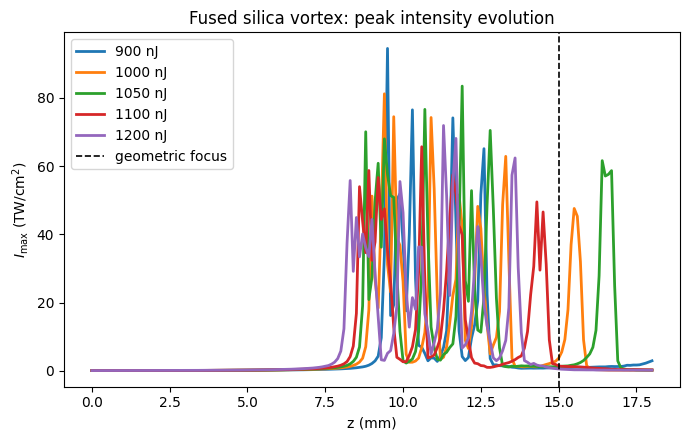

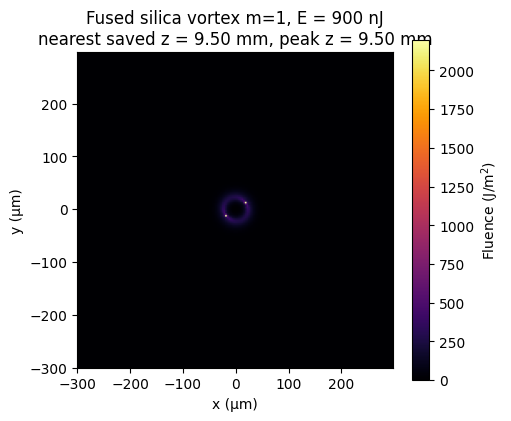

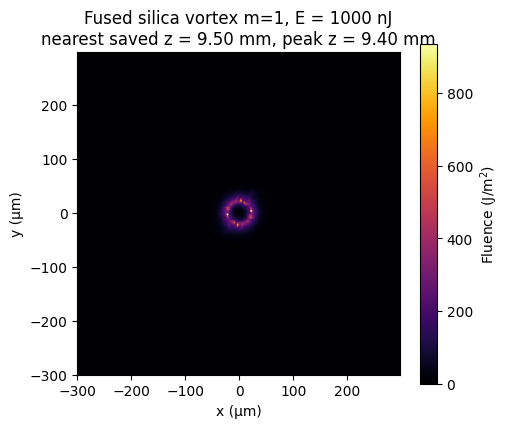

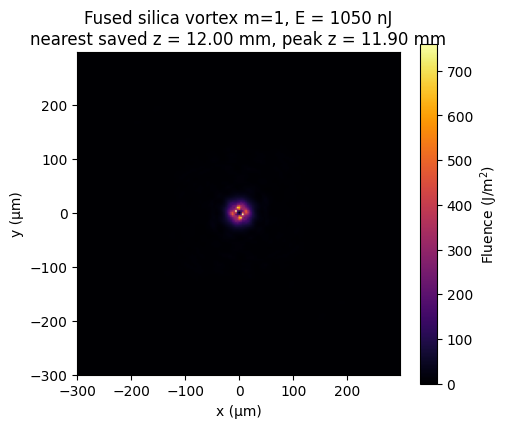

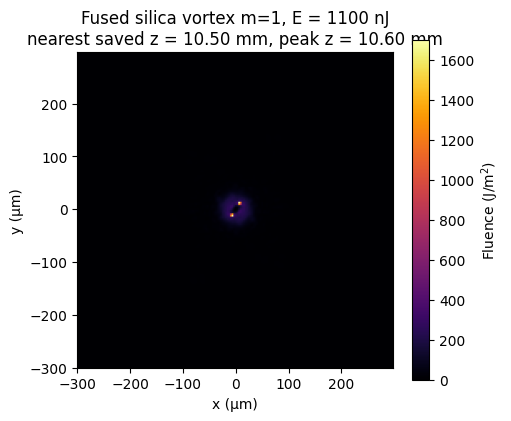

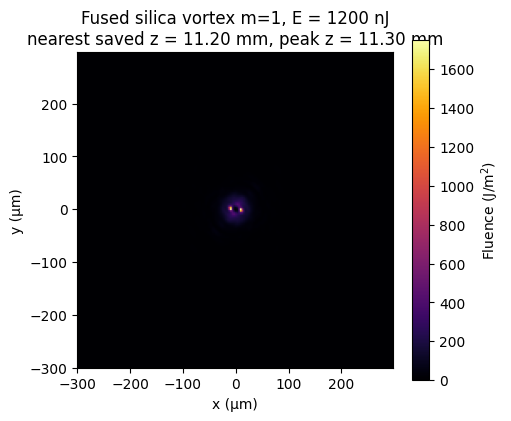

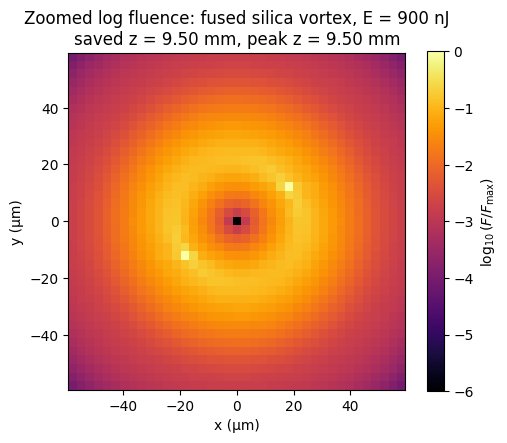

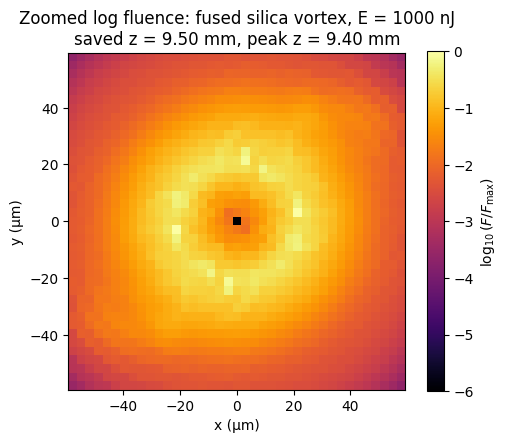

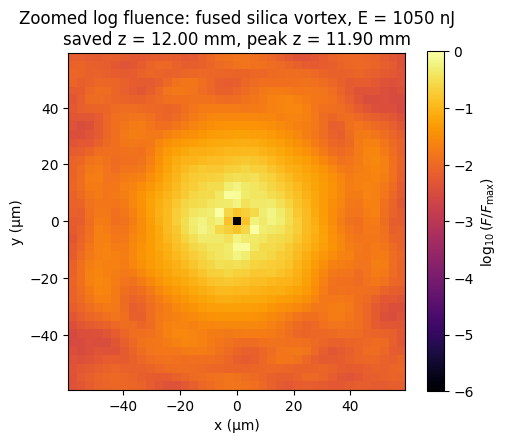

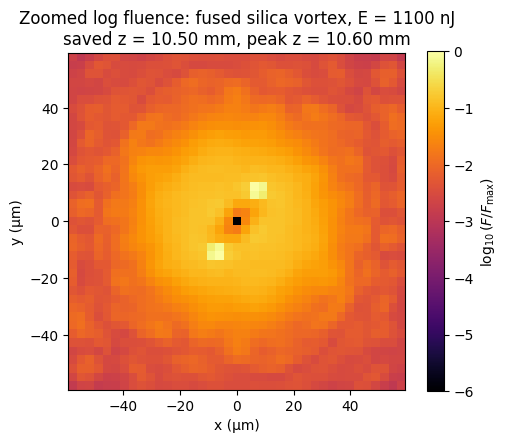

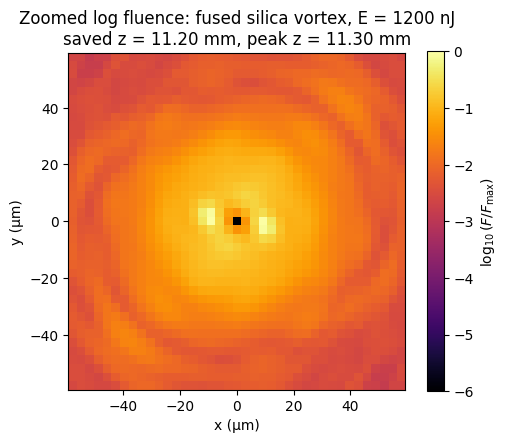

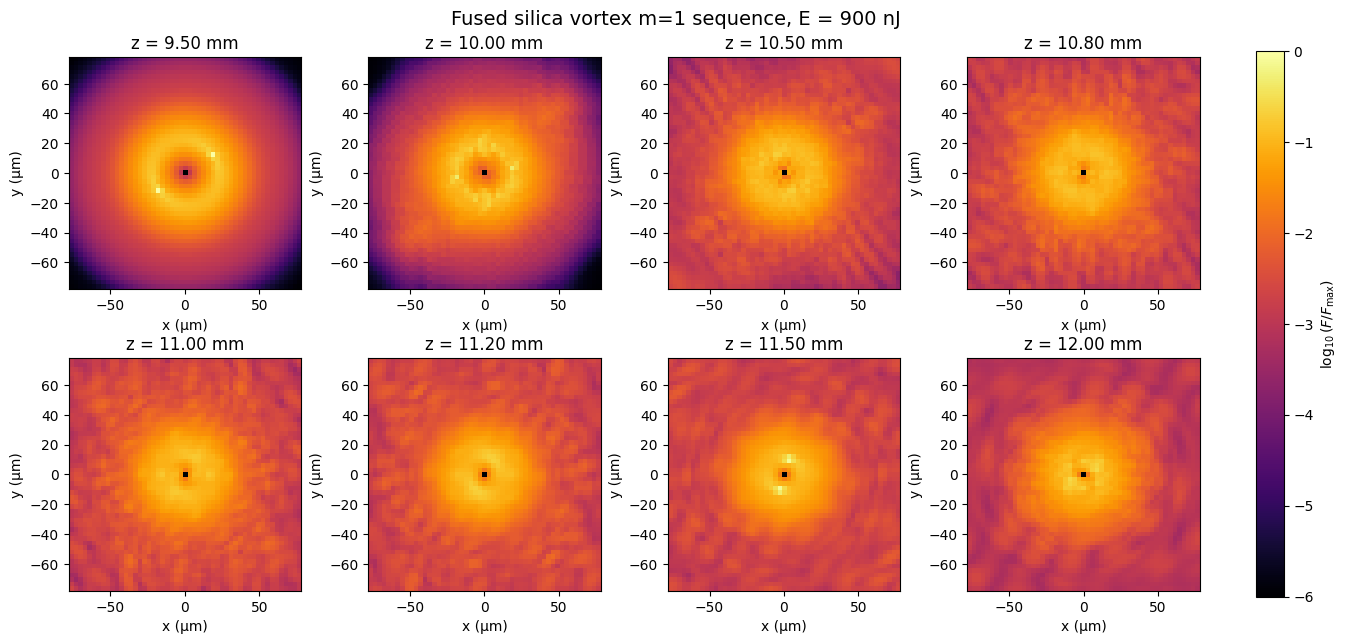

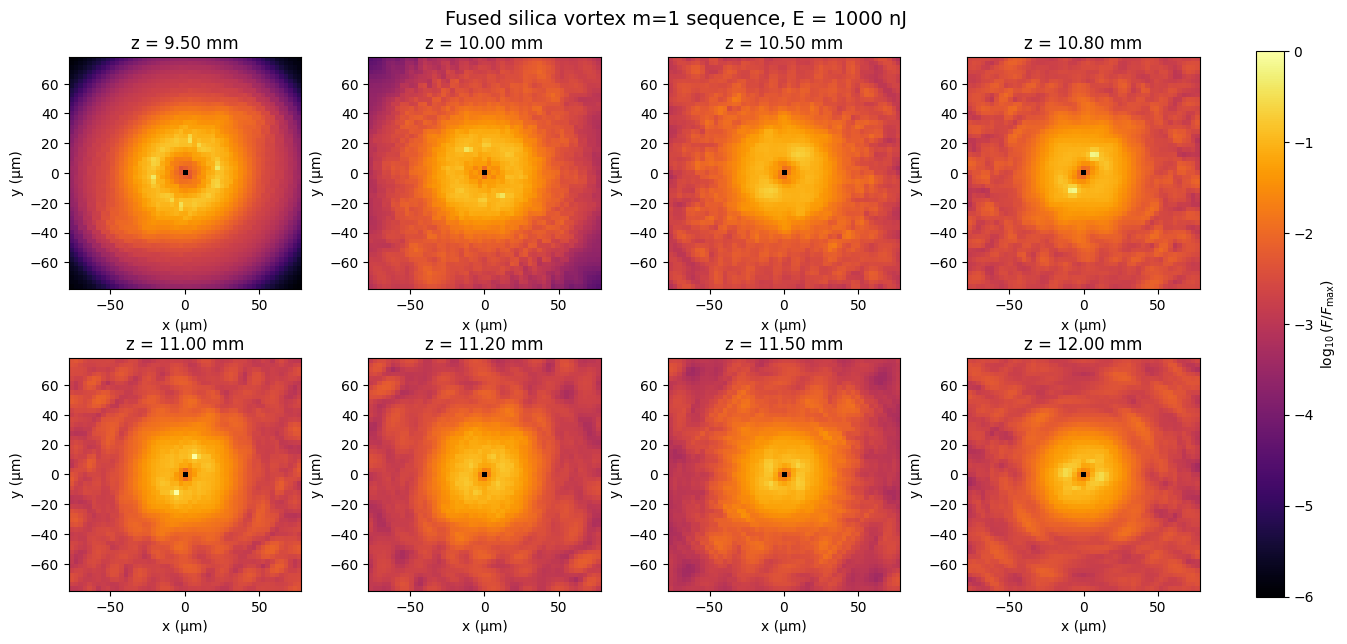

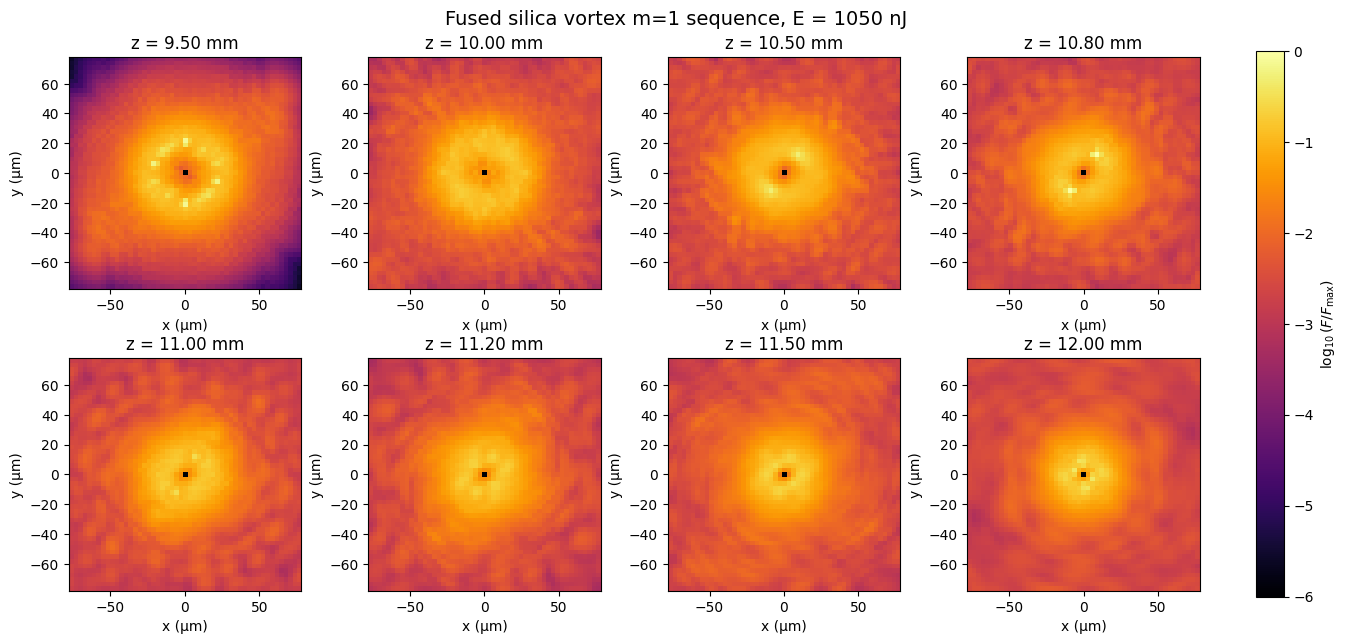

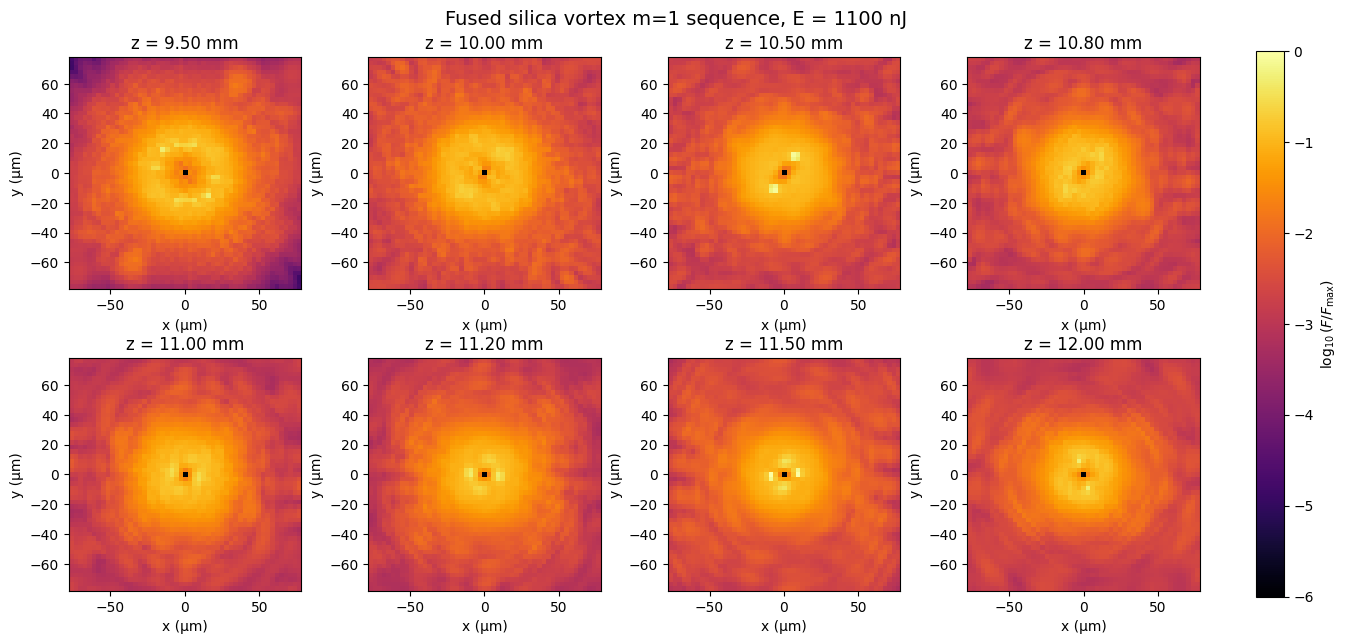

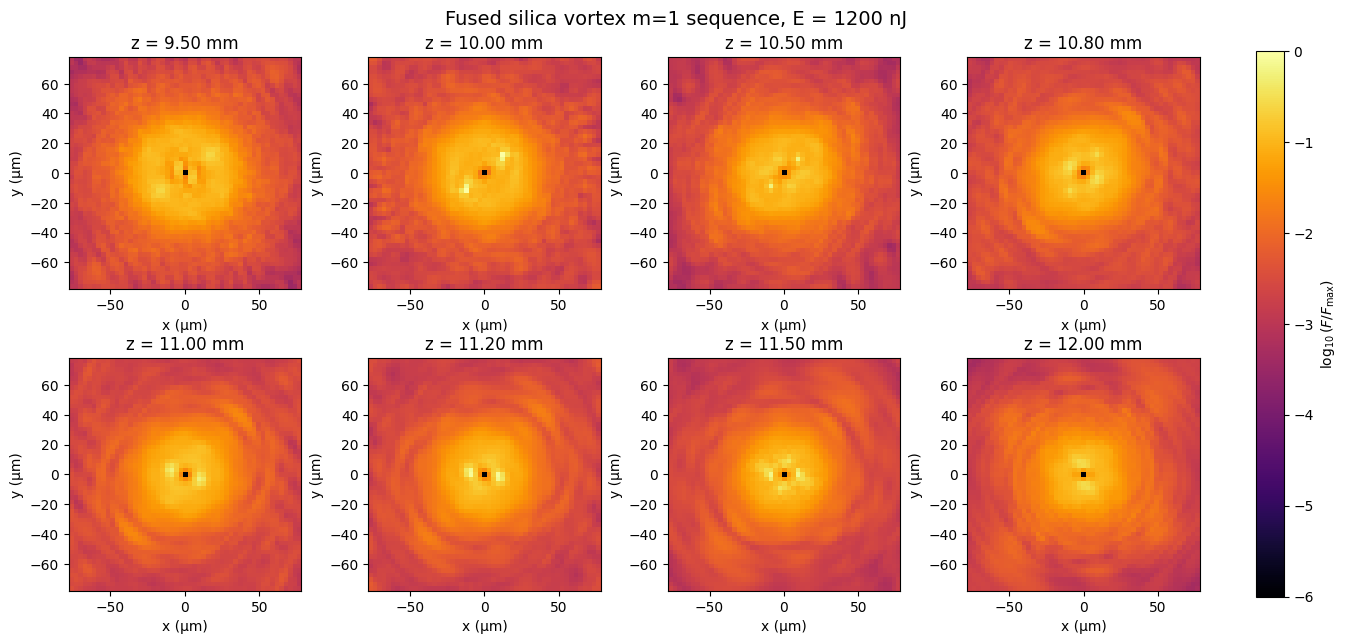

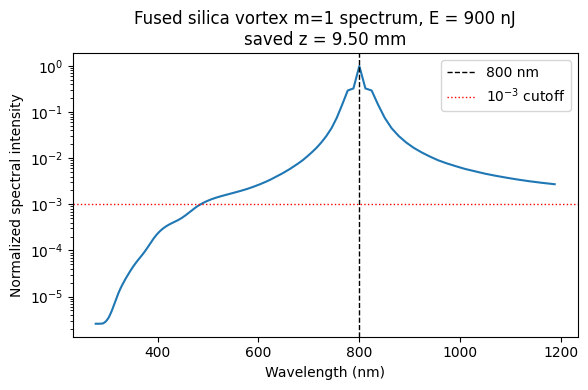

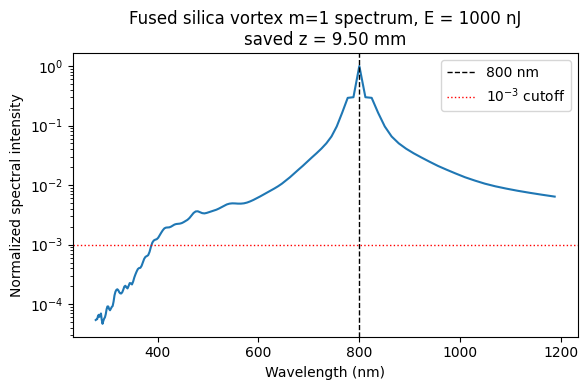

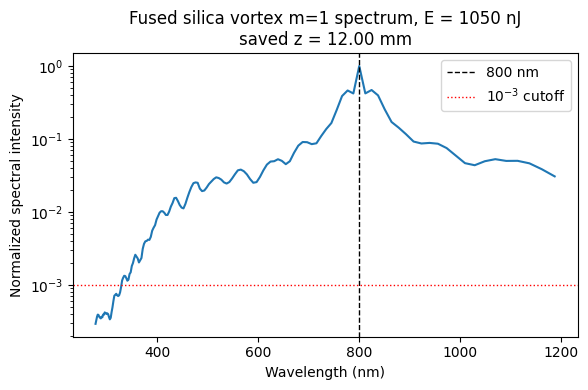

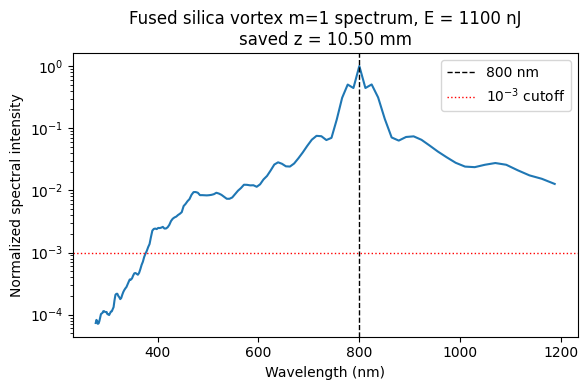

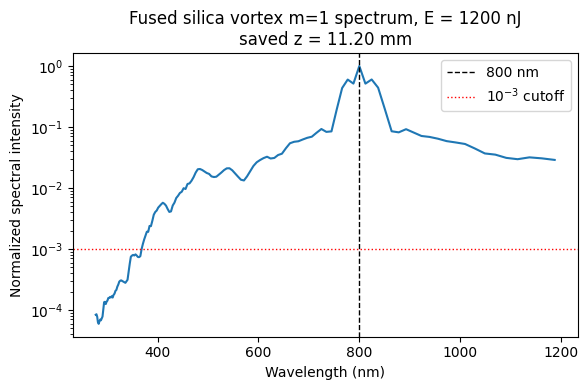


Done. Inspect:
1. The peak-intensity evolution plot.
2. Nearest-collapse fluence maps.
3. Zoomed log-scale maps.
4. Saved z-sequence maps from 9.5 to 12.0 mm.
5. Spectrum near collapse.


In [ ]:
# ============================================================
# Notebook-A1.4 — Fused-silica vortex validation, single-cell version
# Purpose:
#   Validate vortex m=1 nonlinear propagation in fused silica near
#   Liu et al. 2024 vortex self-focusing / filamentation threshold.
#
# Key improvements:
#   - FFT-friendly centered grid
#   - Targeted z-plane saving near collapse
#   - Initial vortex center forced to zero
#   - Small azimuthal perturbation to reveal vortex breakup
#   - Fluence maps near collapse and z-sequence maps
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from scipy.constants import c, epsilon_0, e, m_e, h, pi

# ============================================================
# 1. Physical constants
# ============================================================

lambda0 = 800e-9
omega0 = 2 * pi * c / lambda0
k0_vac = 2 * pi / lambda0

photon_energy_J = h * c / lambda0
photon_energy_eV = photon_energy_J / e

rho_c_m3 = epsilon_0 * m_e * omega0**2 / e**2
rho_c_cm3 = rho_c_m3 / 1e6

print("=" * 70)
print("Notebook-A1.4 — fused-silica vortex validation")
print("=" * 70)
print(f"lambda0               = {lambda0*1e9:.1f} nm")
print(f"photon energy          = {photon_energy_eV:.3f} eV")
print(f"critical density rho_c = {rho_c_cm3:.3e} cm^-3")

# ============================================================
# 2. Material database
# ============================================================

# Important:
# beta_K_cm is from Liu et al. 2024:
# beta^(6) = 8.4e-67 cm^9/W^5
#
# For dI/dz = -beta_K I^K with I in W/m^2 and z in m,
# beta_K_SI = beta_K_cm * 1e(6 - 4K)
# for K = 6, beta_K_SI = beta_K_cm * 1e-18.

materials = {
    "fused_silica": {
        "label": "Fused silica",
        "n0": 1.4533,
        "n2": 3.2e-20,              # m^2/W
        "Ui_eV": 9.0,
        "K": 6,
        "beta_K_cm": 8.4e-67,       # cm^9/W^5
        "sigma": 6.57e-23,          # m^2
        "tau_rec": 150e-15,         # s
        "rho_nt": 2.2e28,           # m^-3
        "k2": 36e-27                # s^2/m
    }
}

for mat in materials.values():
    K = mat["K"]
    mat["Ui_J"] = mat["Ui_eV"] * e
    mat["beta_K_SI"] = mat["beta_K_cm"] * 10**(6 - 4*K)

# Critical power proxy
alpha_gaussian = 1.8962
n0 = materials["fused_silica"]["n0"]
n2 = materials["fused_silica"]["n2"]

Pcr_gaussian = alpha_gaussian * lambda0**2 / (4 * np.pi * n0 * n2)
Pcr_vortex_proxy = 3.7 * Pcr_gaussian

print("\nMaterial summary:")
material_df = pd.DataFrame([{
    "material": "fused_silica",
    "n0": n0,
    "n2_m2_W": n2,
    "Ui_eV": materials["fused_silica"]["Ui_eV"],
    "K": materials["fused_silica"]["K"],
    "beta_K_SI": materials["fused_silica"]["beta_K_SI"],
    "Pcr_Gaussian_MW": Pcr_gaussian / 1e6,
    "Pcr_vortex_proxy_MW": Pcr_vortex_proxy / 1e6
}])
display(material_df)

# ============================================================
# 3. Beam and numerical settings
# ============================================================

tau_fwhm = 65e-15
f_lens = 15e-3

# Liu et al. settings:
w0_vortex = 0.060e-3
m_charge = 1

# Grid
Nx = 192
Ny = 192
Nt = 256

Lx = 600e-6
Ly = 600e-6
T_window = 180e-15

# FFT-friendly endpoint=False style grid
dx = Lx / Nx
dy = Ly / Ny
dt = T_window / Nt

x = (np.arange(Nx) - Nx//2) * dx
y = (np.arange(Ny) - Ny//2) * dy
t = (np.arange(Nt) - Nt//2) * dt

X, Y = np.meshgrid(x, y, indexing="xy")
R = np.sqrt(X**2 + Y**2)
PHI = np.arctan2(Y, X)

# Frequency grids
kx = 2 * np.pi * np.fft.fftfreq(Nx, d=dx)
ky = 2 * np.pi * np.fft.fftfreq(Ny, d=dy)
Omega = 2 * np.pi * np.fft.fftfreq(Nt, d=dt)

KX, KY = np.meshgrid(kx, ky, indexing="xy")
KPERP2 = KX**2 + KY**2

# Propagation
Z_MAX = 18e-3
DZ = 100e-6
SAVE_EVERY = 20

# Save planes near collapse region observed previously
z_save_targets = np.array([
    9.5, 10.0, 10.5, 10.8, 11.0, 11.2, 11.5, 12.0
]) * 1e-3

# Energies for validation
vortex_energies_J = np.array([900, 1000, 1050, 1100, 1200]) * 1e-9
# vortex_energies_J = np.array([800, 900, 950, 1000, 1050, 1100, 1200]) * 1e-9
# vortex_energies_J = np.array([1000, 1100]) * 1e-9

# Perturbation settings
ENABLE_VORTEX_PERTURBATION = True
PERTURBATION_LEVEL = 0.02
PERTURBATION_MODE = 2

# Estimated temporal bandwidth lower wavelength
omega_max = omega0 + np.max(np.abs(Omega))
lambda_min_grid = 2 * np.pi * c / omega_max

print("\nReference beam settings:")
print(f"tau_FWHM       = {tau_fwhm*1e15:.1f} fs")
print(f"f_lens         = {f_lens*1e3:.1f} mm")
print(f"Vortex w0      = {w0_vortex*1e3:.3f} mm")
print(f"m_charge       = {m_charge}")

print("\nNumerical grid:")
print(f"Nx, Ny, Nt       = {Nx}, {Ny}, {Nt}")
print(f"dx, dy           = {dx*1e6:.3f}, {dy*1e6:.3f} um")
print(f"dt               = {dt*1e15:.3f} fs")
print(f"T_window         = {T_window*1e15:.1f} fs")
print(f"z_max            = {Z_MAX*1e3:.1f} mm")
print(f"dz               = {DZ*1e6:.1f} um")
print(f"estimated λ_min  = {lambda_min_grid*1e9:.1f} nm")

mem_GB = Ny * Nx * Nt * np.dtype(np.complex128).itemsize / 1024**3
print(f"3D complex field memory ≈ {mem_GB:.2f} GB")

# ============================================================
# 4. Utility functions
# ============================================================

def intensity_W_m2(Efield, material="fused_silica"):
    """
    Convert electric field envelope to intensity.
    I = 0.5 n0 eps0 c |E|^2
    """
    n0 = materials[material]["n0"]
    return 0.5 * n0 * epsilon_0 * c * np.abs(Efield)**2


def field_energy_J(Efield, material="fused_silica"):
    """
    Total pulse energy:
    E_pulse = integral I(x,y,t) dx dy dt
    """
    I = intensity_W_m2(Efield, material)
    return np.sum(I) * dx * dy * dt


def scale_to_energy(Efield, target_energy_J, material="fused_silica"):
    """
    Scale field amplitude to desired pulse energy.
    """
    current_energy = field_energy_J(Efield, material)
    if current_energy <= 0:
        raise ValueError("Current field energy is zero or negative.")
    return Efield * np.sqrt(target_energy_J / current_energy)


def peak_intensity_TW_cm2(Efield, material="fused_silica"):
    """
    Peak intensity in TW/cm^2.
    1 TW/cm^2 = 1e16 W/m^2.
    """
    I = intensity_W_m2(Efield, material)
    return np.max(I) / 1e16


def fluence_map(Efield, material="fused_silica"):
    """
    Fluence F(x,y) = integral I(x,y,t) dt.
    Units: J/m^2.
    """
    I = intensity_W_m2(Efield, material)
    return np.sum(I, axis=2) * dt


def spectrum_integrated(Efield):
    """
    Integrated temporal spectrum over x,y.
    Returns wavelength grid and normalized spectral intensity.

    Uses envelope frequency:
    omega_abs = omega0 + Omega.
    """
    Ew = np.fft.fft(Efield, axis=2)
    S_omega = np.sum(np.abs(Ew)**2, axis=(0, 1))

    omega_abs = omega0 + Omega
    valid = omega_abs > 0

    omega_valid = omega_abs[valid]
    S_valid = S_omega[valid]

    wavelength = 2 * np.pi * c / omega_valid

    # Sort by wavelength ascending
    order = np.argsort(wavelength)
    wavelength = wavelength[order]
    S_valid = S_valid[order]

    if np.max(S_valid) > 0:
        S_norm = S_valid / np.max(S_valid)
    else:
        S_norm = S_valid

    return wavelength, S_norm


def blue_cutoff_nm(Efield, threshold=1e-3):
    """
    Blue-side cutoff wavelength:
    smallest wavelength with normalized spectral intensity >= threshold.
    """
    wavelength, S_norm = spectrum_integrated(Efield)
    mask_blue = wavelength < lambda0
    mask = mask_blue & (S_norm >= threshold)

    if not np.any(mask):
        return np.nan

    return np.min(wavelength[mask]) * 1e9


# ============================================================
# 5. Initial vortex field
# ============================================================

def build_vortex_field(energy_J, material="fused_silica"):
    """
    Build focused m=1 vortex pulse:
    E ~ (r/w0)^m exp(-r^2/(2w0^2)) exp(i m phi)
        exp(-t^2/(2 sigma_t^2))
        exp(-i k r^2/(2f))
    """
    mat = materials[material]
    n0 = mat["n0"]
    k_med = n0 * k0_vac

    # Temporal amplitude width.
    # Intensity FWHM = tau_fwhm.
    sigma_t = tau_fwhm / (2 * np.sqrt(np.log(2)))

    # Real radial vortex envelope
    spatial = (R / w0_vortex)**abs(m_charge)
    spatial *= np.exp(-R**2 / (2 * w0_vortex**2))

    # Convert to complex before applying phase factors
    spatial = spatial.astype(np.complex128)

    # Vortex phase
    spatial *= np.exp(1j * m_charge * PHI)

    # Focusing lens phase
    lens_phase = np.exp(-1j * k_med * R**2 / (2 * f_lens))
    spatial *= lens_phase

    # Force exact vortex center zero
    spatial[Ny//2, Nx//2] = 0.0 + 0.0j

    # Small azimuthal perturbation to encourage physical symmetry breaking
    if ENABLE_VORTEX_PERTURBATION:
        perturb = 1.0 + PERTURBATION_LEVEL * np.cos(PERTURBATION_MODE * PHI)
        spatial *= perturb

    temporal = np.exp(-t**2 / (2 * sigma_t**2))

    E0 = spatial[:, :, None] * temporal[None, None, :]

    # Ensure exact central null in full 3D field initially
    E0[Ny//2, Nx//2, :] = 0.0 + 0.0j

    E0 = scale_to_energy(E0, energy_J, material)

    return E0.astype(np.complex128)



# ============================================================
# 6. Propagation operators
# ============================================================

def linear_step(Efield, dz, material="fused_silica"):
    """
    Linear split-step:
    - transverse diffraction
    - group velocity dispersion
    """
    mat = materials[material]
    n0 = mat["n0"]
    k2 = mat["k2"]

    k_med = n0 * k0_vac

    # Shapes:
    # KPERP2: (Ny, Nx)
    # Omega:  (Nt,)
    phase_diff = -1j * KPERP2[:, :, None] * dz / (2 * k_med)
    phase_gvd = -1j * 0.5 * k2 * Omega[None, None, :]**2 * dz

    H = np.exp(phase_diff + phase_gvd)

    Ef = np.fft.fftn(Efield, axes=(0, 1, 2))
    Ef *= H
    return np.fft.ifftn(Ef, axes=(0, 1, 2))


def plasma_density_from_intensity(I, material="fused_silica"):
    """
    Local plasma density generated within the pulse.

    Solves approximately:
    d rho / dt = beta_K I^K / Ui + sigma rho I / Ui - rho/tau_rec

    Vectorized over x,y; loop only over temporal index.
    """
    mat = materials[material]

    K = mat["K"]
    beta_K = mat["beta_K_SI"]
    Ui_J = mat["Ui_J"]
    sigma = mat["sigma"]
    tau_rec = mat["tau_rec"]
    rho_nt = mat["rho_nt"]

    rho = np.zeros_like(I)

    # Photoionization source
    # Units roughly m^-3 s^-1
    photo_rate = beta_K * np.maximum(I, 0.0)**K / Ui_J

    # Time stepping inside pulse
    rho_prev = np.zeros(I.shape[:2], dtype=np.float64)

    for it in range(Nt):
        I_slice = I[:, :, it]

        avalanche_rate = sigma * rho_prev * I_slice / Ui_J
        recomb_rate = rho_prev / tau_rec

        drho_dt = photo_rate[:, :, it] + avalanche_rate - recomb_rate

        rho_new = rho_prev + dt * drho_dt
        rho_new = np.clip(rho_new, 0.0, rho_nt)

        rho[:, :, it] = rho_new
        rho_prev = rho_new

    return rho


def nonlinear_step(Efield, dz, material="fused_silica"):
    """
    Nonlinear step:
    - Kerr phase
    - plasma defocusing phase
    - multiphoton absorption
    - collision/inverse Bremsstrahlung absorption proxy
    """
    mat = materials[material]

    n0 = mat["n0"]
    n2 = mat["n2"]
    K = mat["K"]
    beta_K = mat["beta_K_SI"]
    sigma = mat["sigma"]

    I = intensity_W_m2(Efield, material)
    rho = plasma_density_from_intensity(I, material)

    # Kerr nonlinear phase
    phi_kerr = k0_vac * n2 * I * dz

    # Plasma defocusing phase
    # From Liu-type term: -i k0 rho/(2 n0 rho_c)
    phi_plasma = -k0_vac * rho * dz / (2 * n0 * rho_c_m3)

    phase = np.exp(1j * (phi_kerr + phi_plasma))

    # Absorption:
    # amplitude loss = exp[-0.5 * alpha dz]
    alpha_mpa = beta_K * np.maximum(I, 0.0)**(K - 1)
    alpha_collision = sigma * rho

    loss_arg = -0.5 * (alpha_mpa + alpha_collision) * dz

    # Safety cap to avoid rare numerical blow-up
    loss_arg = np.clip(loss_arg, -0.05, 0.0)

    Eout = Efield * phase * np.exp(loss_arg)

    return Eout, rho


# ============================================================
# 7. Propagation solver
# ============================================================

def propagate(
    E0,
    material="fused_silica",
    z_max=Z_MAX,
    dz=DZ,
    save_every=SAVE_EVERY,
    z_save_targets=None
):
    """
    Split-step propagation.
    Saves:
    - regular interval maps,
    - final map,
    - requested target z-plane maps.
    """
    Nz = int(np.round(z_max / dz)) + 1
    z = np.linspace(0, z_max, Nz)

    Efield = E0.copy()

    peak_I = np.zeros(Nz)
    energy = np.zeros(Nz)
    max_rho = np.zeros(Nz)

    saved = {}

    target_indices = set()
    if z_save_targets is not None:
        for zt in z_save_targets:
            idx = int(np.argmin(np.abs(z - zt)))
            target_indices.add(idx)

    t_start = time.time()

    for iz, zz in enumerate(z):
        peak_I[iz] = peak_intensity_TW_cm2(Efield, material)
        energy[iz] = field_energy_J(Efield, material)

        should_save_regular = (iz % save_every == 0)
        should_save_target = (iz in target_indices)
        should_save_final = (iz == Nz - 1)

        if should_save_regular or should_save_target or should_save_final:
            saved[zz] = {
                "fluence": fluence_map(Efield, material),
                "cutoff_nm": blue_cutoff_nm(Efield),
                "spectrum": spectrum_integrated(Efield)
            }

        if iz < Nz - 1:
            Efield = linear_step(Efield, dz / 2, material)
            Efield, rho = nonlinear_step(Efield, dz, material)
            max_rho[iz] = np.max(rho)
            Efield = linear_step(Efield, dz / 2, material)

    if Nz > 1:
        max_rho[-1] = max_rho[-2]

    runtime = time.time() - t_start

    return {
        "material": material,
        "z": z,
        "E_final": Efield,
        "peak_I_TW_cm2": peak_I,
        "energy_J": energy,
        "max_rho_m3": max_rho,
        "saved": saved,
        "runtime_s": runtime
    }


# ============================================================
# 8. Run vortex validation scan
# ============================================================

def run_vortex_scan():
    outputs = {}
    rows = []

    print("\n" + "=" * 70)
    print("Running fused-silica vortex m=1 validation scan")
    print("=" * 70)

    for energy_J in vortex_energies_J:
        energy_nJ = energy_J * 1e9

        peak_power_est = energy_J / tau_fwhm

        print(
            f"Running fused_silica | vortex_m1 | "
            f"energy = {energy_nJ:7.1f} nJ | "
            f"P_est = {peak_power_est/1e6:6.2f} MW"
        )

        E0 = build_vortex_field(energy_J, material="fused_silica")

        # Initial central-null diagnostic
        center_initial = np.max(np.abs(E0[Ny//2, Nx//2, :]))
        print(f"  initial center |E| max = {center_initial:.3e}")

        out = propagate(
            E0,
            material="fused_silica",
            z_max=Z_MAX,
            dz=DZ,
            save_every=SAVE_EVERY,
            z_save_targets=z_save_targets
        )

        outputs[energy_J] = out

        z_arr = out["z"]
        peak_I = out["peak_I_TW_cm2"]

        idx_peak = int(np.argmax(peak_I))
        z_Imax = z_arr[idx_peak]

        cutoff_values = [
            item["cutoff_nm"]
            for item in out["saved"].values()
            if not np.isnan(item["cutoff_nm"])
        ]

        cutoff_min = np.min(cutoff_values) if len(cutoff_values) else np.nan

        energy_loss_pct = 100 * (1 - out["energy_J"][-1] / out["energy_J"][0])

        rows.append({
            "material": "fused_silica",
            "beam_type": "vortex_m1",
            "energy_nJ": energy_nJ,
            "peak_power_MW_est": peak_power_est / 1e6,
            "Imax_TW_cm2": np.max(peak_I),
            "z_Imax_mm": z_Imax * 1e3,
            "cutoff_nm": cutoff_min,
            "energy_loss_pct": energy_loss_pct,
            "max_rho_cm3": np.max(out["max_rho_m3"]) / 1e6,
            "runtime_s": out["runtime_s"]
        })

    df = pd.DataFrame(rows)

    print("\nFused-silica vortex validation table:")
    display(df)

    df.to_csv("A1_4_vortex_fused_silica_validation.csv", index=False)
    print("Saved: A1_4_vortex_fused_silica_validation.csv")

    return outputs, df


vortex_fs_outputs_fast, vortex_fs_df = run_vortex_scan()

# ============================================================
# 9. Plot peak intensity evolution
# ============================================================

plt.figure(figsize=(7, 4.5))

for energy_J, out in vortex_fs_outputs_fast.items():
    plt.plot(
        out["z"] * 1e3,
        out["peak_I_TW_cm2"],
        lw=2,
        label=f"{energy_J*1e9:.0f} nJ"
    )

plt.axvline(f_lens * 1e3, color="k", ls="--", lw=1.2, label="geometric focus")
plt.xlabel("z (mm)")
plt.ylabel(r"$I_{\max}$ (TW/cm$^2$)")
plt.title("Fused silica vortex: peak intensity evolution")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 10. Plot nearest-collapse fluence maps
# ============================================================

def plot_nearest_fluence_map(output, title="Fluence map"):
    z_arr = output["z"]
    I_arr = output["peak_I_TW_cm2"]
    z_peak = z_arr[np.argmax(I_arr)]

    saved_z = np.array(sorted(output["saved"].keys()))
    z_near = saved_z[np.argmin(np.abs(saved_z - z_peak))]

    F = output["saved"][z_near]["fluence"]

    plt.figure(figsize=(5.2, 4.4))
    plt.imshow(
        F,
        origin="lower",
        extent=[x[0]*1e6, x[-1]*1e6, y[0]*1e6, y[-1]*1e6],
        cmap="inferno",
        aspect="equal"
    )
    plt.colorbar(label=r"Fluence (J/m$^2$)")
    plt.xlabel("x (µm)")
    plt.ylabel("y (µm)")
    plt.title(
        f"{title}\n"
        f"nearest saved z = {z_near*1e3:.2f} mm, "
        f"peak z = {z_peak*1e3:.2f} mm"
    )
    plt.tight_layout()
    plt.show()


for energy_J, out in vortex_fs_outputs_fast.items():
    plot_nearest_fluence_map(
        out,
        title=f"Fused silica vortex m=1, E = {energy_J*1e9:.0f} nJ"
    )

# ============================================================
# 11. Zoomed log-scale nearest-collapse maps
# ============================================================

def plot_nearest_fluence_zoom(
    output,
    title="Zoomed fluence map",
    half_width_um=60,
    log_floor=1e-6
):
    z_arr = output["z"]
    I_arr = output["peak_I_TW_cm2"]
    z_peak = z_arr[np.argmax(I_arr)]

    saved_z = np.array(sorted(output["saved"].keys()))
    z_near = saved_z[np.argmin(np.abs(saved_z - z_peak))]

    F = output["saved"][z_near]["fluence"]

    X_um = x * 1e6
    Y_um = y * 1e6

    ix = np.where(np.abs(X_um) <= half_width_um)[0]
    iy = np.where(np.abs(Y_um) <= half_width_um)[0]

    F_crop = F[np.ix_(iy, ix)]

    F_plot = np.log10(F_crop / np.max(F_crop) + log_floor)

    plt.figure(figsize=(5.2, 4.4))
    plt.imshow(
        F_plot,
        origin="lower",
        extent=[
            X_um[ix[0]], X_um[ix[-1]],
            Y_um[iy[0]], Y_um[iy[-1]]
        ],
        cmap="inferno",
        aspect="equal",
        vmin=np.log10(log_floor),
        vmax=0
    )
    plt.colorbar(label=r"$\log_{10}(F/F_{\max})$")
    plt.xlabel("x (µm)")
    plt.ylabel("y (µm)")
    plt.title(
        f"{title}\n"
        f"saved z = {z_near*1e3:.2f} mm, "
        f"peak z = {z_peak*1e3:.2f} mm"
    )
    plt.tight_layout()
    plt.show()


for energy_J, out in vortex_fs_outputs_fast.items():
    plot_nearest_fluence_zoom(
        out,
        title=f"Zoomed log fluence: fused silica vortex, E = {energy_J*1e9:.0f} nJ",
        half_width_um=60
    )

# ============================================================
# 12. Plot saved z-sequence near collapse
# ============================================================

def plot_saved_fluence_sequence(
    output,
    title="Fluence sequence",
    z_min_mm=9.5,
    z_max_mm=12.0,
    half_width_um=80,
    log_floor=1e-6
):
    saved_z = np.array(sorted(output["saved"].keys()))

    keep = (saved_z * 1e3 >= z_min_mm) & (saved_z * 1e3 <= z_max_mm)
    saved_z = saved_z[keep]

    if len(saved_z) == 0:
        print("No saved maps found in requested z range.")
        return

    X_um = x * 1e6
    Y_um = y * 1e6

    ix = np.where(np.abs(X_um) <= half_width_um)[0]
    iy = np.where(np.abs(Y_um) <= half_width_um)[0]

    n = len(saved_z)
    ncols = min(4, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(3.35*ncols, 3.15*nrows),
        constrained_layout=True
    )

    axes = np.array(axes).reshape(nrows, ncols)

    global_max = max(
        np.max(output["saved"][zz]["fluence"][np.ix_(iy, ix)])
        for zz in saved_z
    )

    for ax, zz in zip(axes.ravel(), saved_z):
        F = output["saved"][zz]["fluence"]
        F_crop = F[np.ix_(iy, ix)]

        F_plot = np.log10(F_crop / global_max + log_floor)

        im = ax.imshow(
            F_plot,
            origin="lower",
            extent=[
                X_um[ix[0]], X_um[ix[-1]],
                Y_um[iy[0]], Y_um[iy[-1]]
            ],
            cmap="inferno",
            aspect="equal",
            vmin=np.log10(log_floor),
            vmax=0
        )

        ax.set_title(f"z = {zz*1e3:.2f} mm")
        ax.set_xlabel("x (µm)")
        ax.set_ylabel("y (µm)")

    for ax in axes.ravel()[n:]:
        ax.axis("off")

    fig.colorbar(im, ax=axes.ravel().tolist(), label=r"$\log_{10}(F/F_{\max})$")
    fig.suptitle(title, fontsize=14)
    plt.show()


for energy_J, out in vortex_fs_outputs_fast.items():
    plot_saved_fluence_sequence(
        out,
        title=f"Fused silica vortex m=1 sequence, E = {energy_J*1e9:.0f} nJ",
        z_min_mm=9.5,
        z_max_mm=12.0,
        half_width_um=80
    )

# ============================================================
# 13. Plot example spectrum near collapse
# ============================================================

def plot_nearest_spectrum(output, title="Spectrum near collapse"):
    z_arr = output["z"]
    I_arr = output["peak_I_TW_cm2"]
    z_peak = z_arr[np.argmax(I_arr)]

    saved_z = np.array(sorted(output["saved"].keys()))
    z_near = saved_z[np.argmin(np.abs(saved_z - z_peak))]

    wavelength, S_norm = output["saved"][z_near]["spectrum"]

    keep = (wavelength > 250e-9) & (wavelength < 1200e-9)

    plt.figure(figsize=(6, 4))
    plt.semilogy(wavelength[keep] * 1e9, S_norm[keep] + 1e-20)
    plt.axvline(lambda0 * 1e9, color="k", ls="--", lw=1, label="800 nm")
    plt.axhline(1e-3, color="r", ls=":", lw=1, label=r"$10^{-3}$ cutoff")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Normalized spectral intensity")
    plt.title(
        f"{title}\n"
        f"saved z = {z_near*1e3:.2f} mm"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()


for energy_J, out in vortex_fs_outputs_fast.items():
    plot_nearest_spectrum(
        out,
        title=f"Fused silica vortex m=1 spectrum, E = {energy_J*1e9:.0f} nJ"
    )

print("\nDone. Inspect:")
print("1. The peak-intensity evolution plot.")
print("2. Nearest-collapse fluence maps.")
print("3. Zoomed log-scale maps.")
print("4. Saved z-sequence maps from 9.5 to 12.0 mm.")
print("5. Spectrum near collapse.")


,energy_nJ,peak_power_MW_est,Imax_TW_cm2,z_Imax_mm,final_cutoff_nm,max_rho_cm3,energy_loss_pct
0,900.0,13.846154,94.480963,9.5,277.509518,1.234931e+18,0.516857
1,1000.0,15.384615,81.186121,9.4,314.736675,4.210714e+17,0.472452
2,1050.0,16.153846,83.436316,11.9,311.107609,6.784122e+17,0.538987
3,1100.0,16.923077,65.664863,10.6,277.509518,3.009422e+17,0.447605
4,1200.0,18.461538,71.890216,11.3,316.583143,4.494099e+17,0.380167


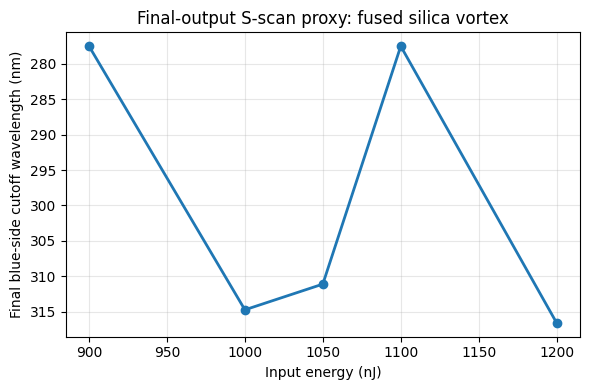

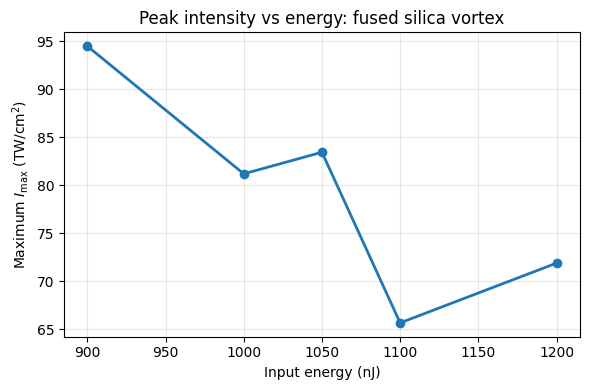

In [ ]:
# ============================================================
# Final-output S-scan diagnostic from existing vortex results
# No rerun needed
# ============================================================

def final_blue_cutoff_nm_from_output(out, threshold=1e-3):
    E_final = out["E_final"]
    wavelength, S_norm = spectrum_integrated(E_final)

    mask_blue = wavelength < lambda0
    mask = mask_blue & (S_norm >= threshold)

    if not np.any(mask):
        return np.nan

    return np.min(wavelength[mask]) * 1e9


rows_final = []

for energy_J, out in vortex_fs_outputs_fast.items():
    E_final = out["E_final"]

    cutoff_final = final_blue_cutoff_nm_from_output(out, threshold=1e-3)

    z_arr = out["z"]
    I_arr = out["peak_I_TW_cm2"]
    idx_peak = np.argmax(I_arr)

    rows_final.append({
        "energy_nJ": energy_J * 1e9,
        "peak_power_MW_est": energy_J / tau_fwhm / 1e6,
        "Imax_TW_cm2": np.max(I_arr),
        "z_Imax_mm": z_arr[idx_peak] * 1e3,
        "final_cutoff_nm": cutoff_final,
        "max_rho_cm3": np.max(out["max_rho_m3"]) / 1e6,
        "energy_loss_pct": 100 * (1 - out["energy_J"][-1] / out["energy_J"][0])
    })

final_scan_df = pd.DataFrame(rows_final).sort_values("energy_nJ")
display(final_scan_df)

plt.figure(figsize=(6, 4))
plt.plot(final_scan_df["energy_nJ"], final_scan_df["final_cutoff_nm"], "o-", lw=2)
plt.gca().invert_yaxis()
plt.xlabel("Input energy (nJ)")
plt.ylabel("Final blue-side cutoff wavelength (nm)")
plt.title("Final-output S-scan proxy: fused silica vortex")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(final_scan_df["energy_nJ"], final_scan_df["Imax_TW_cm2"], "o-", lw=2)
plt.xlabel("Input energy (nJ)")
plt.ylabel(r"Maximum $I_{\max}$ (TW/cm$^2$)")
plt.title("Peak intensity vs energy: fused silica vortex")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


,material,label,n0,n2_m2_W,Ui_eV,K,beta_K_SI,k2_s2_m
0,fused_silica,Fused silica,1.4533,3.200000e-20,9.0,6,8.400000e-85,3.600000e-26
1,sapphire_o,Sapphire ordinary,1.7600,3.000000e-20,8.8,6,8.400000e-85,7.000000e-26
2,sapphire_e,Sapphire extraordinary,1.7520,3.000000e-20,8.8,6,8.400000e-85,7.000000e-26



Running vortex m=1 scan for material = sapphire_o
Running sapphire_o | vortex_m1 | E =   700.0 nJ | P_est =  10.77 MW
  initial center |E| max = 0.000e+00
Running sapphire_o | vortex_m1 | E =   900.0 nJ | P_est =  13.85 MW
  initial center |E| max = 0.000e+00
Running sapphire_o | vortex_m1 | E =  1000.0 nJ | P_est =  15.38 MW
  initial center |E| max = 0.000e+00
Running sapphire_o | vortex_m1 | E =  1100.0 nJ | P_est =  16.92 MW
  initial center |E| max = 0.000e+00
Running sapphire_o | vortex_m1 | E =  1200.0 nJ | P_est =  18.46 MW
  initial center |E| max = 0.000e+00

sapphire_o vortex scan table:


,material,beam_type,energy_nJ,peak_power_MW_est,Imax_TW_cm2,z_Imax_mm,final_cutoff_nm,energy_loss_pct,max_rho_cm3,runtime_s
0,sapphire_o,vortex_m1,700.0,10.769231,51.881026,11.2,398.385578,0.436109,4.153253e+17,982.158287
1,sapphire_o,vortex_m1,900.0,13.846154,63.376297,9.3,386.958511,0.520676,4.333353e+17,985.310969
2,sapphire_o,vortex_m1,1000.0,15.384615,66.121537,9.3,392.588910,0.663446,1.092454e+18,983.459419
3,sapphire_o,vortex_m1,1100.0,16.923077,66.210024,11.2,386.958511,0.592553,5.421581e+17,977.197283
4,sapphire_o,vortex_m1,1200.0,18.461538,74.755678,10.4,378.809345,0.643148,2.209365e+18,983.770072


Saved: A1_5_sapphire_o_vortex_scan.csv


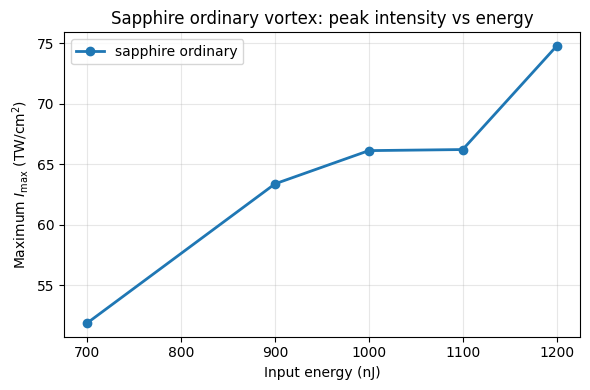

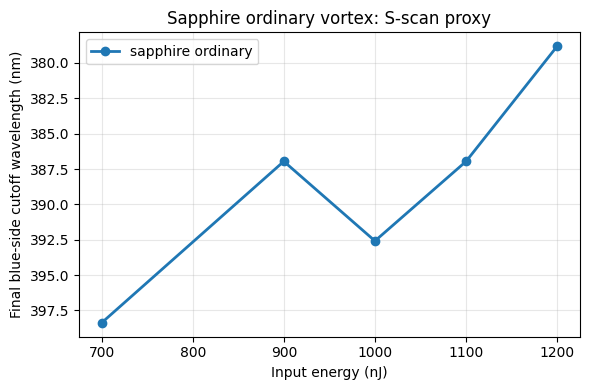

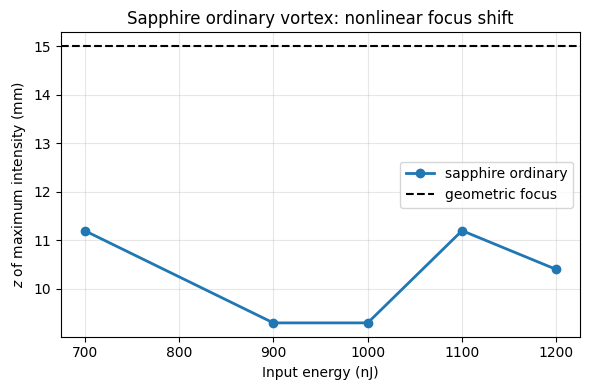

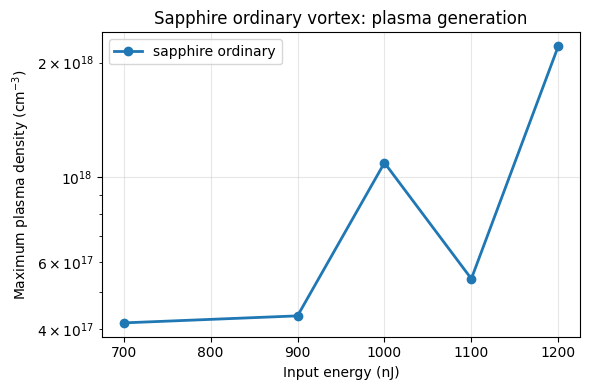

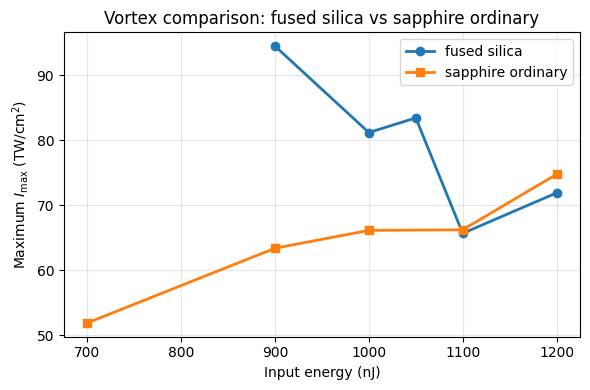

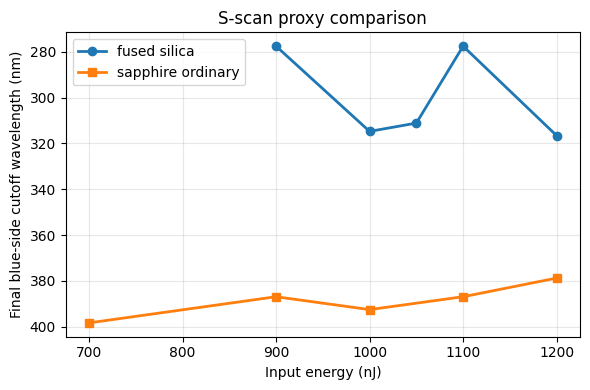

In [ ]:
# ============================================================
# Notebook-A1.5 — Sapphire vortex extension
# Run this AFTER Notebook-A1.4 fused-silica validation.
#
# Purpose:
#   Use the validated fused-silica vortex framework and replace
#   the material with sapphire ordinary / extraordinary.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Add sapphire materials to existing material database
# ============================================================

# Important:
# These sapphire beta_K and sigma values are first-pass proxies.
# They should be described as calibration/sensitivity parameters.
# For the first sapphire comparison, we keep beta_K and sigma equal
# to fused silica so that the material difference comes mainly from:
# n0, n2, Ui, k2.

materials["sapphire_o"] = {
    "label": "Sapphire ordinary",
    "n0": 1.7600,
    "n2": 3.0e-20,              # m^2/W, approximate
    "Ui_eV": 8.8,               # eV, approximate
    "K": 6,
    "beta_K_cm": 8.4e-67,       # proxy, same as fused silica for first comparison
    "sigma": 6.57e-23,          # proxy
    "tau_rec": 150e-15,         # proxy
    "rho_nt": 2.35e28,          # approximate neutral density, m^-3
    "k2": 70e-27                # s^2/m, placeholder
}

materials["sapphire_e"] = {
    "label": "Sapphire extraordinary",
    "n0": 1.7520,
    "n2": 3.0e-20,              # m^2/W, approximate
    "Ui_eV": 8.8,               # eV, approximate
    "K": 6,
    "beta_K_cm": 8.4e-67,       # proxy
    "sigma": 6.57e-23,          # proxy
    "tau_rec": 150e-15,         # proxy
    "rho_nt": 2.35e28,          # approximate neutral density, m^-3
    "k2": 70e-27                # s^2/m, placeholder
}

# Add derived quantities for new materials
for mat_name in ["sapphire_o", "sapphire_e"]:
    mat = materials[mat_name]
    K = mat["K"]
    mat["Ui_J"] = mat["Ui_eV"] * e
    mat["beta_K_SI"] = mat["beta_K_cm"] * 10**(6 - 4*K)

# Display material comparison
material_compare_df = pd.DataFrame([
    {
        "material": key,
        "label": val["label"],
        "n0": val["n0"],
        "n2_m2_W": val["n2"],
        "Ui_eV": val["Ui_eV"],
        "K": val["K"],
        "beta_K_SI": val["beta_K_SI"],
        "k2_s2_m": val["k2"]
    }
    for key, val in materials.items()
])

display(material_compare_df)

# ============================================================
# 2. Use wider targeted save planes for sapphire
# ============================================================

# Sapphire collapse may occur earlier/later than fused silica.
z_save_targets_sapphire = np.array([
    6.0, 7.0, 8.0, 9.0, 9.5, 10.0, 10.5,
    11.0, 11.5, 12.0, 13.0, 14.0, 15.0
]) * 1e-3

# Sapphire energies.
# Start with a modest scan. Runtime will be long.
sapphire_energies_J = np.array([700, 900, 1000, 1100, 1200]) * 1e-9

# ============================================================
# 3. Final-output cutoff helper
# ============================================================

def final_blue_cutoff_nm_from_output(out, threshold=1e-3):
    E_final = out["E_final"]
    wavelength, S_norm = spectrum_integrated(E_final)

    mask_blue = wavelength < lambda0
    mask = mask_blue & (S_norm >= threshold)

    if not np.any(mask):
        return np.nan

    return np.min(wavelength[mask]) * 1e9


# ============================================================
# 4. Generic material scan function
# ============================================================

def run_material_vortex_scan(material_name, energies_J):
    outputs = {}
    rows = []

    print("\n" + "=" * 70)
    print(f"Running vortex m=1 scan for material = {material_name}")
    print("=" * 70)

    for energy_J in energies_J:
        energy_nJ = energy_J * 1e9
        peak_power_est_MW = energy_J / tau_fwhm / 1e6

        print(
            f"Running {material_name} | vortex_m1 | "
            f"E = {energy_nJ:7.1f} nJ | "
            f"P_est = {peak_power_est_MW:6.2f} MW"
        )

        E0 = build_vortex_field(energy_J, material=material_name)

        center_initial = np.max(np.abs(E0[Ny//2, Nx//2, :]))
        print(f"  initial center |E| max = {center_initial:.3e}")

        out = propagate(
            E0,
            material=material_name,
            z_max=Z_MAX,
            dz=DZ,
            save_every=SAVE_EVERY,
            z_save_targets=z_save_targets_sapphire
        )

        outputs[energy_J] = out

        z_arr = out["z"]
        I_arr = out["peak_I_TW_cm2"]
        idx_peak = int(np.argmax(I_arr))

        final_cutoff_nm = final_blue_cutoff_nm_from_output(out, threshold=1e-3)

        energy_loss_pct = 100 * (1 - out["energy_J"][-1] / out["energy_J"][0])

        rows.append({
            "material": material_name,
            "beam_type": "vortex_m1",
            "energy_nJ": energy_nJ,
            "peak_power_MW_est": peak_power_est_MW,
            "Imax_TW_cm2": np.max(I_arr),
            "z_Imax_mm": z_arr[idx_peak] * 1e3,
            "final_cutoff_nm": final_cutoff_nm,
            "energy_loss_pct": energy_loss_pct,
            "max_rho_cm3": np.max(out["max_rho_m3"]) / 1e6,
            "runtime_s": out["runtime_s"]
        })

    df = pd.DataFrame(rows).sort_values("energy_nJ")

    print(f"\n{material_name} vortex scan table:")
    display(df)

    filename = f"A1_5_{material_name}_vortex_scan.csv"
    df.to_csv(filename, index=False)
    print(f"Saved: {filename}")

    return outputs, df


# ============================================================
# 5. Run sapphire ordinary first
# ============================================================

sapphire_o_outputs, sapphire_o_df = run_material_vortex_scan(
    material_name="sapphire_o",
    energies_J=sapphire_energies_J
)

# ============================================================
# 6. Plot sapphire ordinary diagnostics
# ============================================================

plt.figure(figsize=(6, 4))
plt.plot(
    sapphire_o_df["energy_nJ"],
    sapphire_o_df["Imax_TW_cm2"],
    "o-",
    lw=2,
    label="sapphire ordinary"
)
plt.xlabel("Input energy (nJ)")
plt.ylabel(r"Maximum $I_{\max}$ (TW/cm$^2$)")
plt.title("Sapphire ordinary vortex: peak intensity vs energy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(
    sapphire_o_df["energy_nJ"],
    sapphire_o_df["final_cutoff_nm"],
    "o-",
    lw=2,
    label="sapphire ordinary"
)
plt.gca().invert_yaxis()
plt.xlabel("Input energy (nJ)")
plt.ylabel("Final blue-side cutoff wavelength (nm)")
plt.title("Sapphire ordinary vortex: S-scan proxy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(
    sapphire_o_df["energy_nJ"],
    sapphire_o_df["z_Imax_mm"],
    "o-",
    lw=2,
    label="sapphire ordinary"
)
plt.axhline(f_lens * 1e3, color="k", ls="--", label="geometric focus")
plt.xlabel("Input energy (nJ)")
plt.ylabel(r"$z$ of maximum intensity (mm)")
plt.title("Sapphire ordinary vortex: nonlinear focus shift")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.semilogy(
    sapphire_o_df["energy_nJ"],
    sapphire_o_df["max_rho_cm3"],
    "o-",
    lw=2,
    label="sapphire ordinary"
)
plt.xlabel("Input energy (nJ)")
plt.ylabel(r"Maximum plasma density (cm$^{-3}$)")
plt.title("Sapphire ordinary vortex: plasma generation")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 7. Compare with fused silica, if final_scan_df exists
# ============================================================

if "final_scan_df" in globals():
    plt.figure(figsize=(6, 4))
    plt.plot(
        final_scan_df["energy_nJ"],
        final_scan_df["Imax_TW_cm2"],
        "o-",
        lw=2,
        label="fused silica"
    )
    plt.plot(
        sapphire_o_df["energy_nJ"],
        sapphire_o_df["Imax_TW_cm2"],
        "s-",
        lw=2,
        label="sapphire ordinary"
    )
    plt.xlabel("Input energy (nJ)")
    plt.ylabel(r"Maximum $I_{\max}$ (TW/cm$^2$)")
    plt.title("Vortex comparison: fused silica vs sapphire ordinary")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(
        final_scan_df["energy_nJ"],
        final_scan_df["final_cutoff_nm"],
        "o-",
        lw=2,
        label="fused silica"
    )
    plt.plot(
        sapphire_o_df["energy_nJ"],
        sapphire_o_df["final_cutoff_nm"],
        "s-",
        lw=2,
        label="sapphire ordinary"
    )
    plt.gca().invert_yaxis()
    plt.xlabel("Input energy (nJ)")
    plt.ylabel("Final blue-side cutoff wavelength (nm)")
    plt.title("S-scan proxy comparison")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Note: final_scan_df not found. Fused-silica comparison plots skipped.")


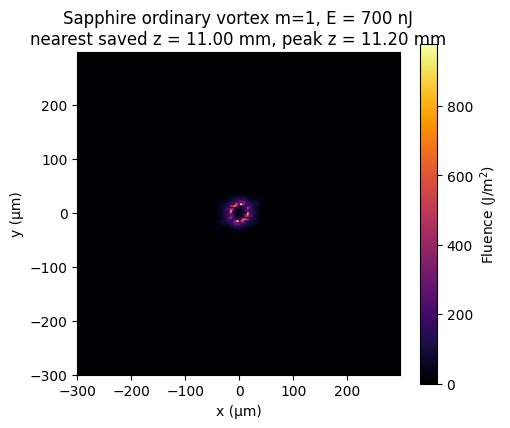

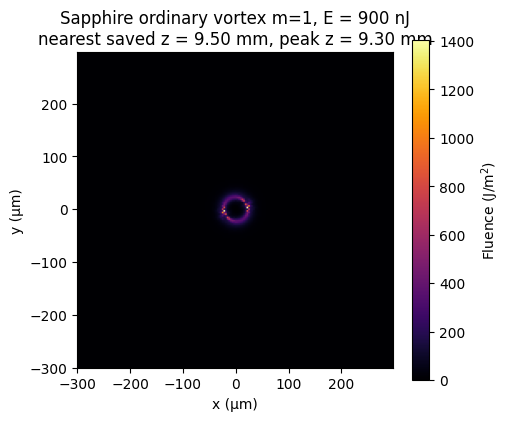

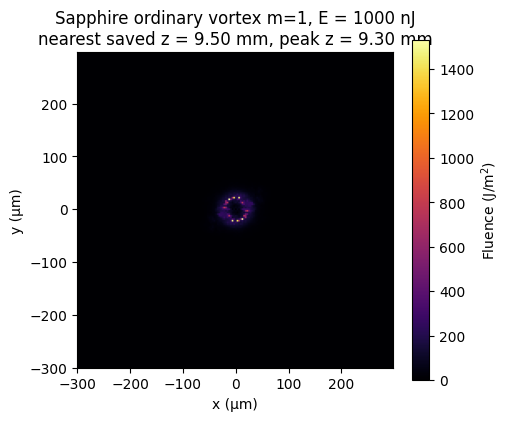

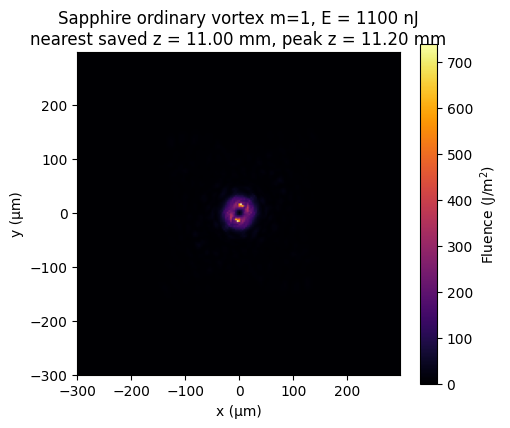

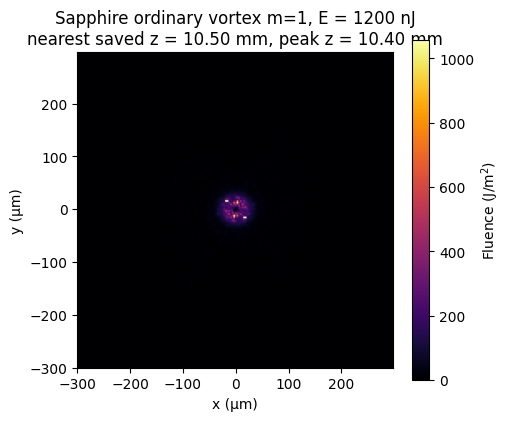

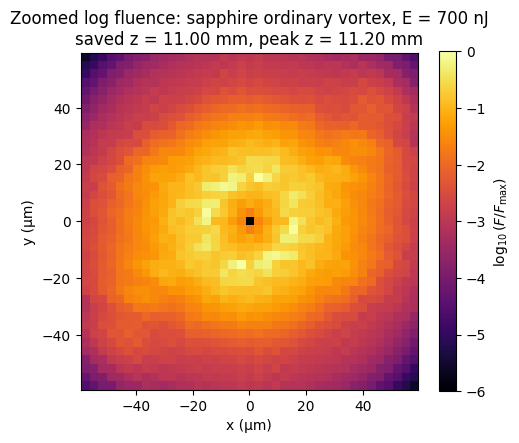

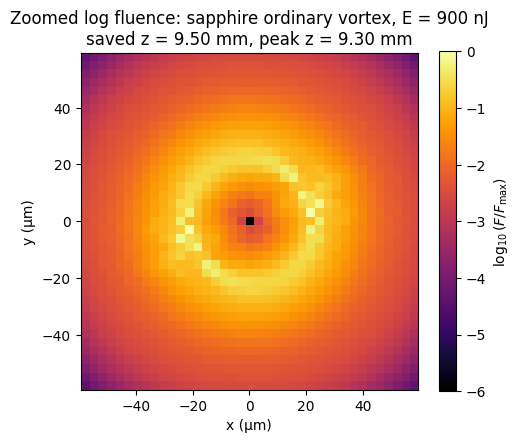

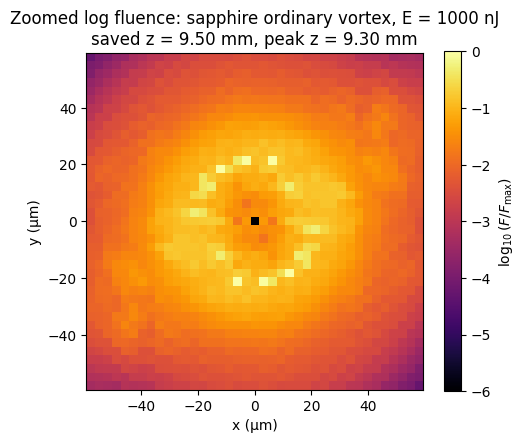

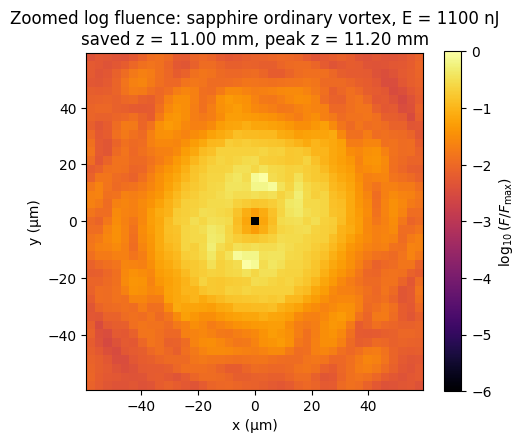

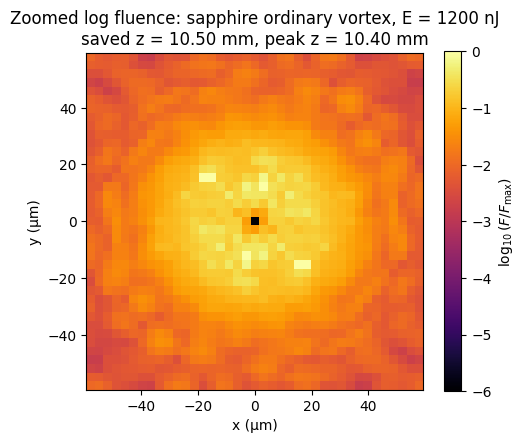

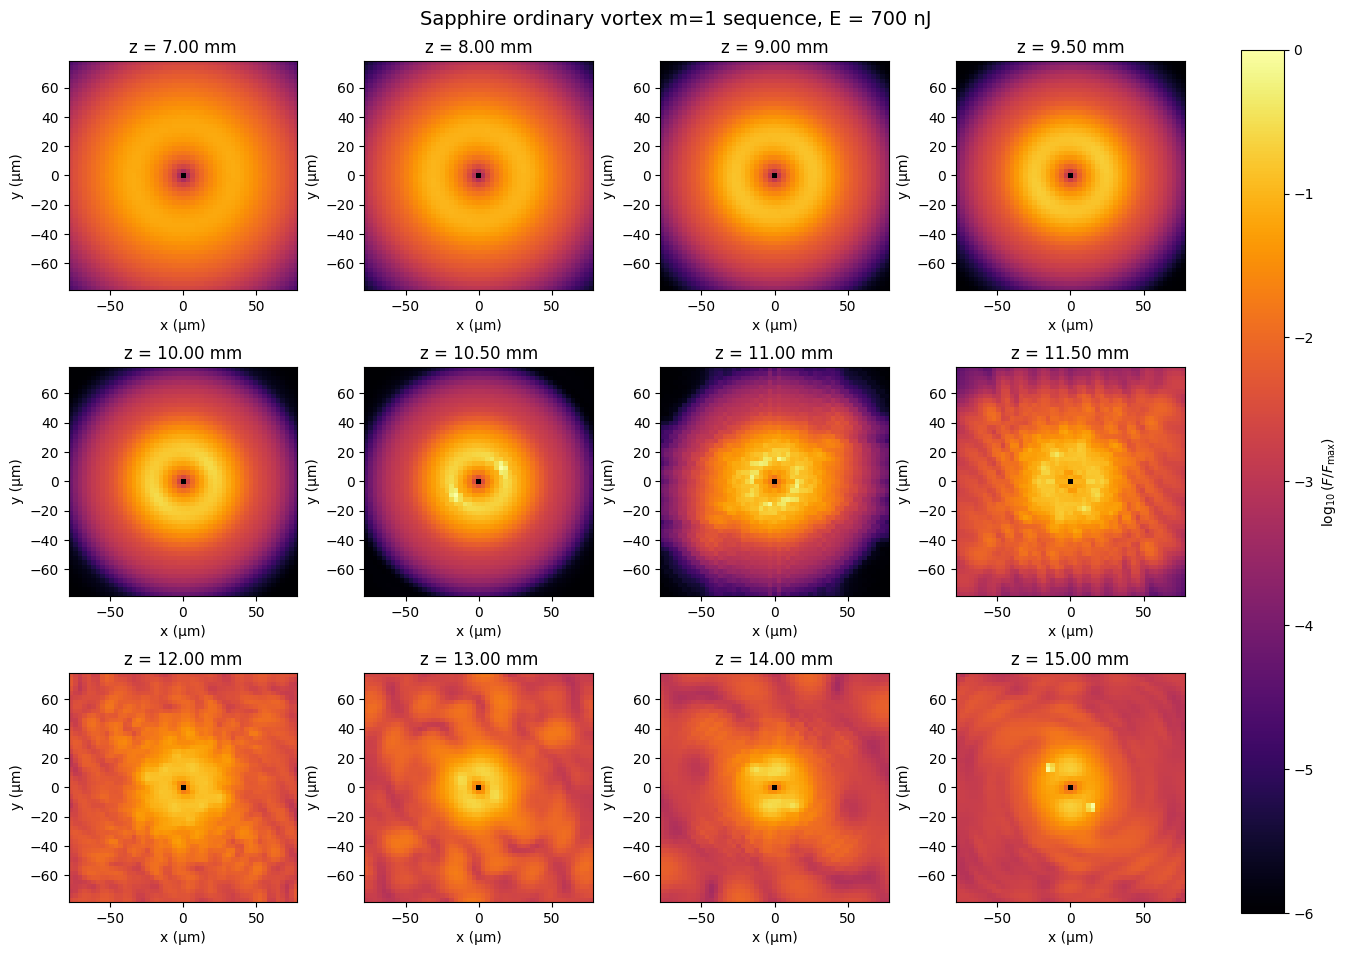

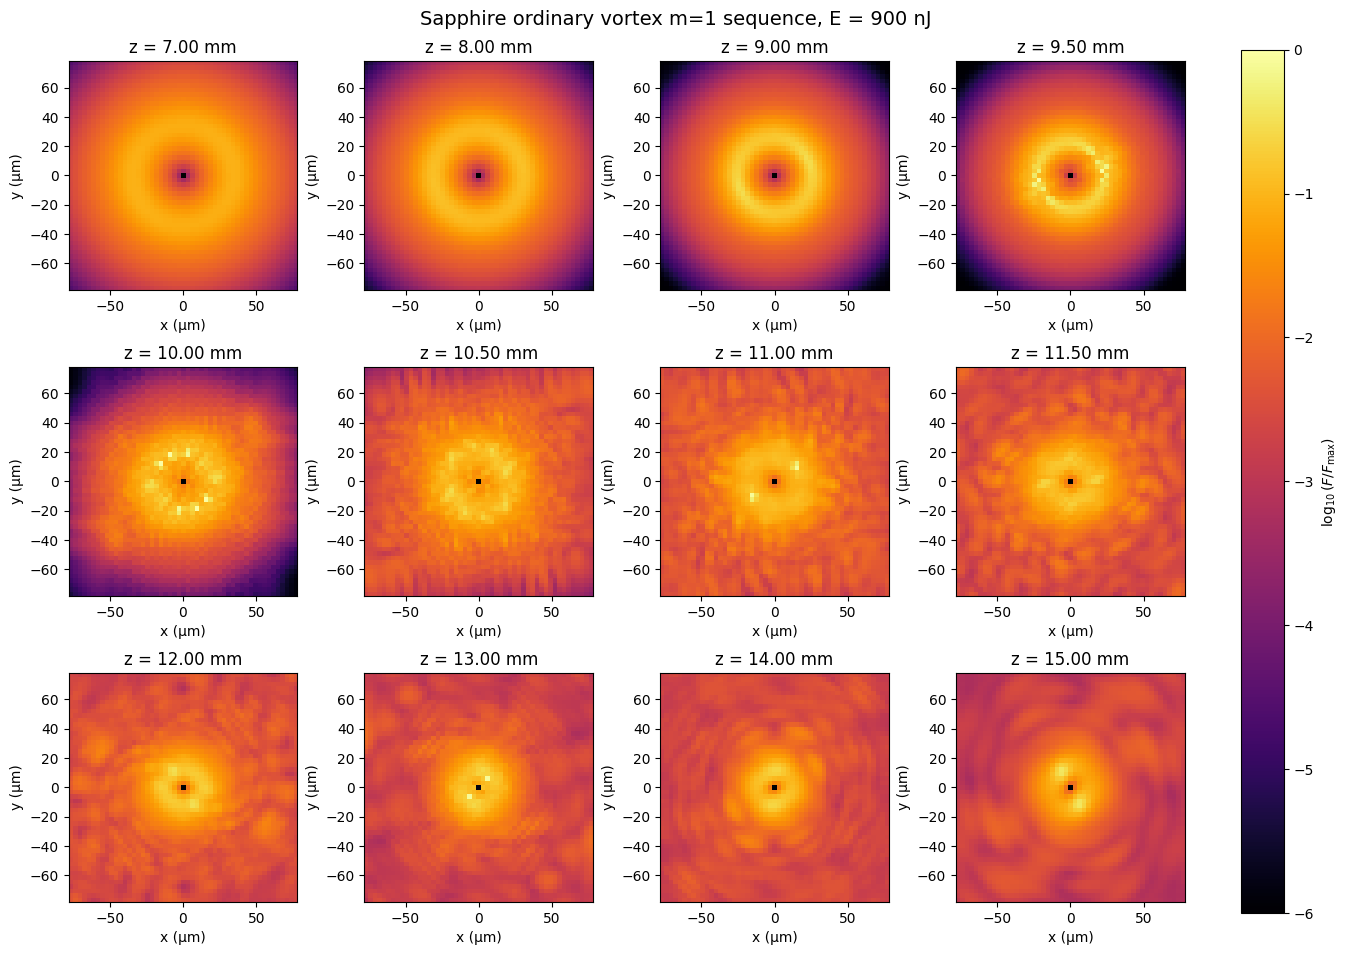

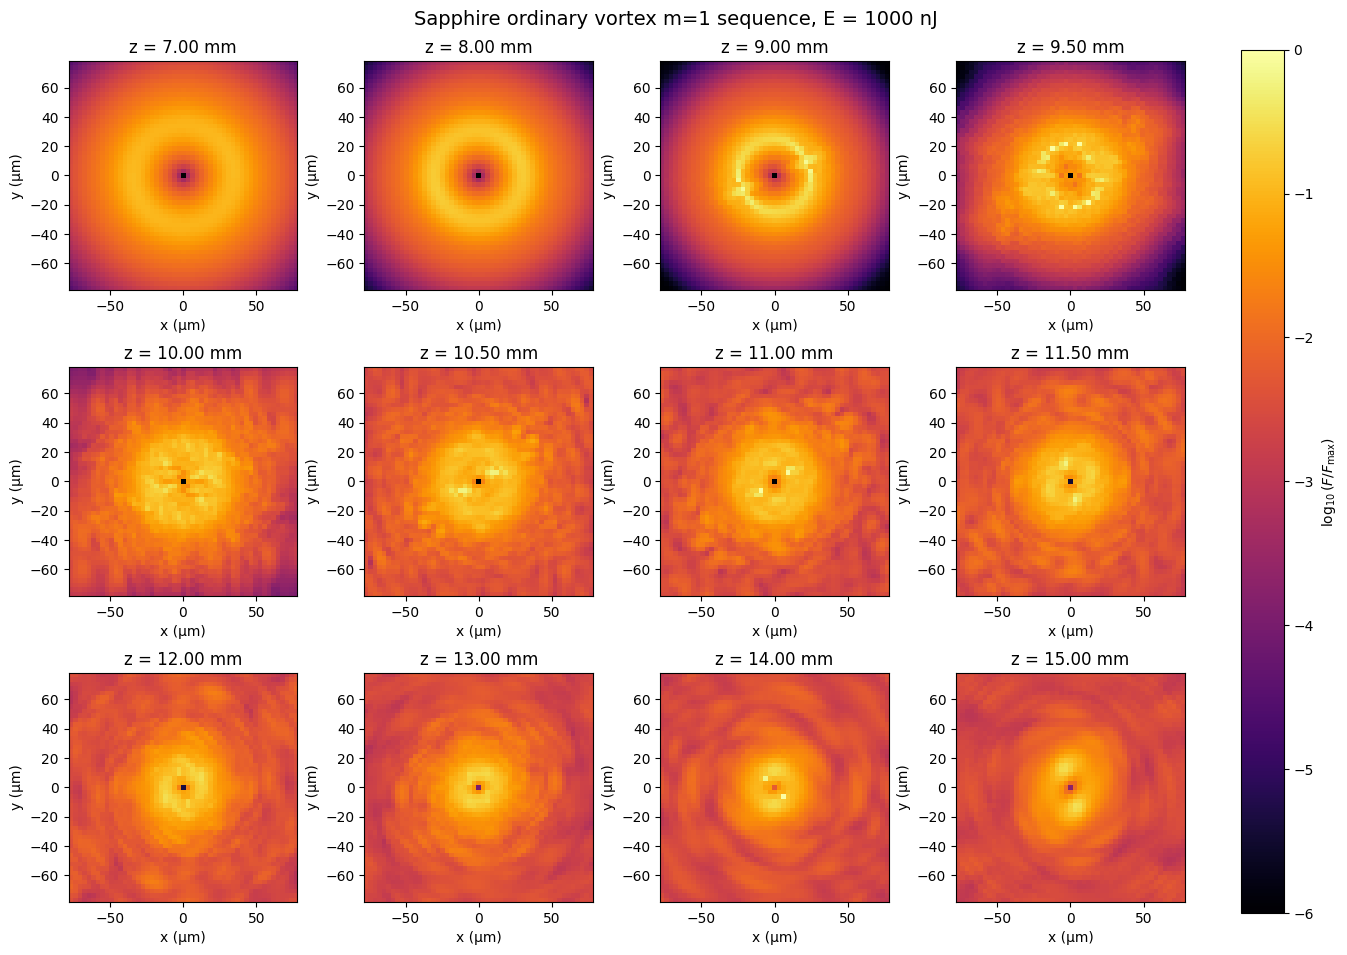

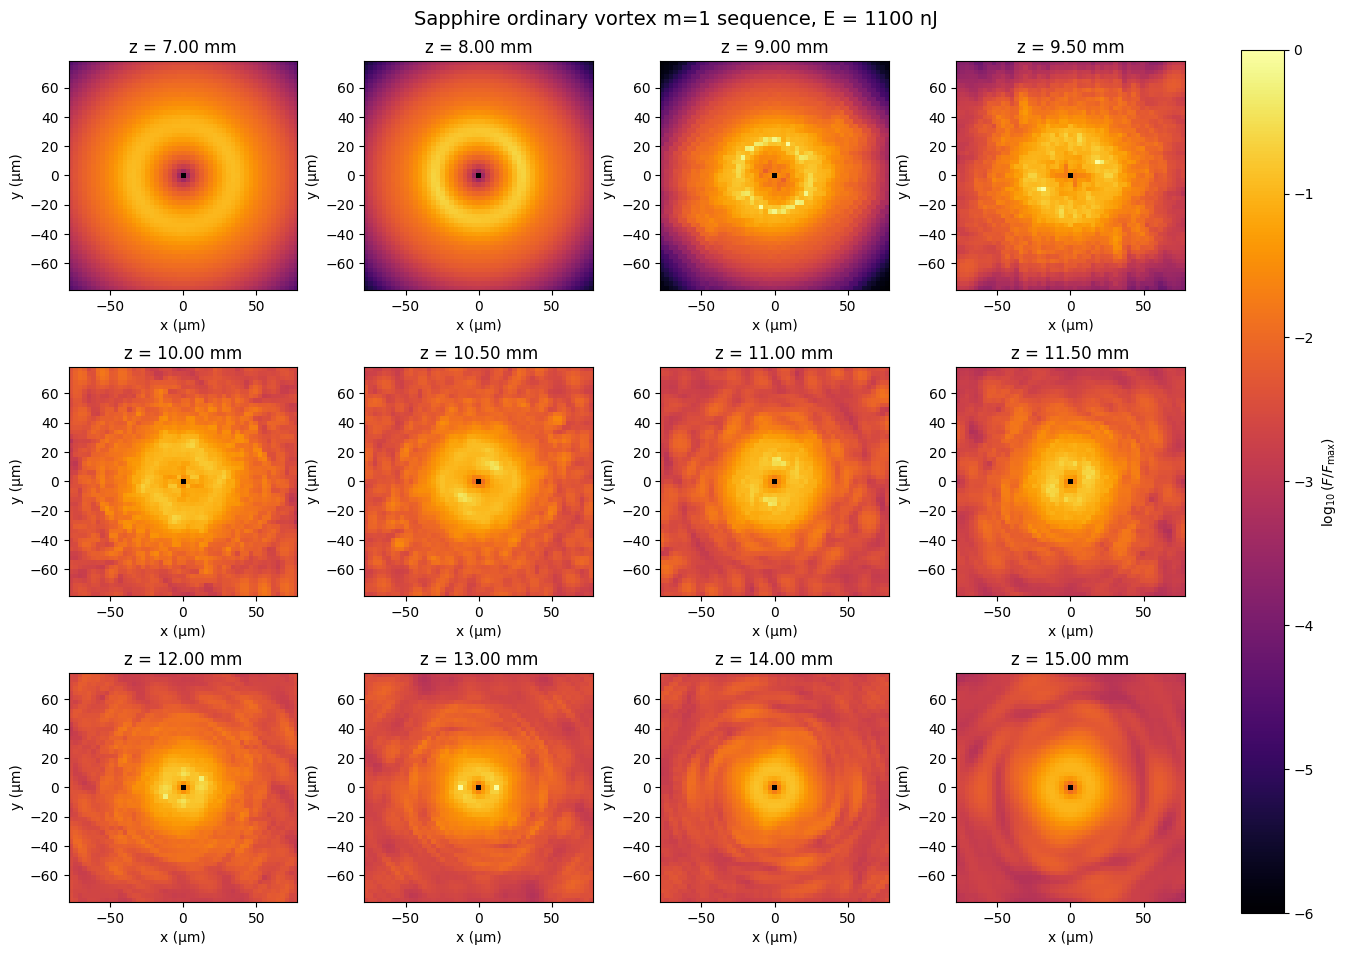

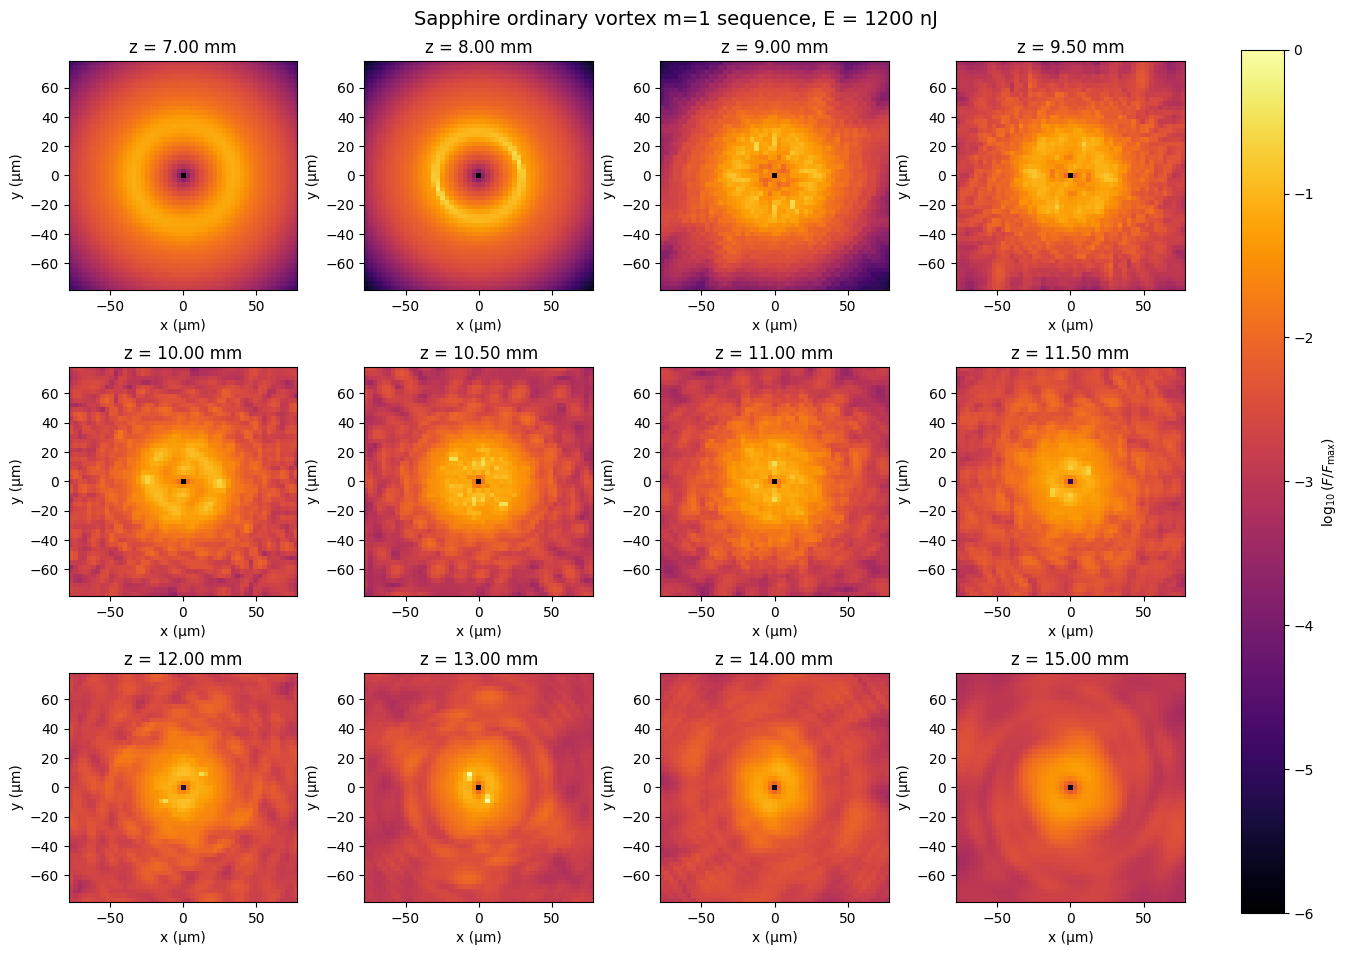

In [ ]:
for energy_J, out in sapphire_o_outputs.items():
    plot_nearest_fluence_map(
        out,
        title=f"Sapphire ordinary vortex m=1, E = {energy_J*1e9:.0f} nJ"
    )

for energy_J, out in sapphire_o_outputs.items():
    plot_nearest_fluence_zoom(
        out,
        title=f"Zoomed log fluence: sapphire ordinary vortex, E = {energy_J*1e9:.0f} nJ",
        half_width_um=60
    )

for energy_J, out in sapphire_o_outputs.items():
    plot_saved_fluence_sequence(
        out,
        title=f"Sapphire ordinary vortex m=1 sequence, E = {energy_J*1e9:.0f} nJ",
        z_min_mm=6.0,
        z_max_mm=15.0,
        half_width_um=80
    )


In [ ]:
sapphire_e_outputs, sapphire_e_df = run_material_vortex_scan(
    material_name="sapphire_e",
    energies_J=sapphire_energies_J
)

sapphire_e_df.to_csv("A1_5_sapphire_e_vortex_scan.csv", index=False)
display(sapphire_e_df)



Running vortex m=1 scan for material = sapphire_e
Running sapphire_e | vortex_m1 | E =   700.0 nJ | P_est =  10.77 MW
  initial center |E| max = 0.000e+00
Running sapphire_e | vortex_m1 | E =   900.0 nJ | P_est =  13.85 MW
  initial center |E| max = 0.000e+00
Running sapphire_e | vortex_m1 | E =  1000.0 nJ | P_est =  15.38 MW
  initial center |E| max = 0.000e+00
Running sapphire_e | vortex_m1 | E =  1100.0 nJ | P_est =  16.92 MW
  initial center |E| max = 0.000e+00
Running sapphire_e | vortex_m1 | E =  1200.0 nJ | P_est =  18.46 MW
  initial center |E| max = 0.000e+00

sapphire_e vortex scan table:


,material,beam_type,energy_nJ,peak_power_MW_est,Imax_TW_cm2,z_Imax_mm,final_cutoff_nm,energy_loss_pct,max_rho_cm3,runtime_s
0,sapphire_e,vortex_m1,700.0,10.769231,52.731492,11.2,407.408809,0.481374,3.206866e+17,981.007707
1,sapphire_e,vortex_m1,900.0,13.846154,61.747445,9.3,410.508075,0.488893,3.930832e+17,979.573466
2,sapphire_e,vortex_m1,1000.0,15.384615,64.198757,9.3,398.385578,0.660495,5.935148e+17,971.656343
3,sapphire_e,vortex_m1,1100.0,16.923077,63.698427,8.5,404.355990,0.468841,3.025625e+17,973.837457
4,sapphire_e,vortex_m1,1200.0,18.461538,66.129126,14.2,373.564614,0.609626,2.395928e+18,976.220029


Saved: A1_5_sapphire_e_vortex_scan.csv


,material,beam_type,energy_nJ,peak_power_MW_est,Imax_TW_cm2,z_Imax_mm,final_cutoff_nm,energy_loss_pct,max_rho_cm3,runtime_s
0,sapphire_e,vortex_m1,700.0,10.769231,52.731492,11.2,407.408809,0.481374,3.206866e+17,981.007707
1,sapphire_e,vortex_m1,900.0,13.846154,61.747445,9.3,410.508075,0.488893,3.930832e+17,979.573466
2,sapphire_e,vortex_m1,1000.0,15.384615,64.198757,9.3,398.385578,0.660495,5.935148e+17,971.656343
3,sapphire_e,vortex_m1,1100.0,16.923077,63.698427,8.5,404.355990,0.468841,3.025625e+17,973.837457
4,sapphire_e,vortex_m1,1200.0,18.461538,66.129126,14.2,373.564614,0.609626,2.395928e+18,976.220029


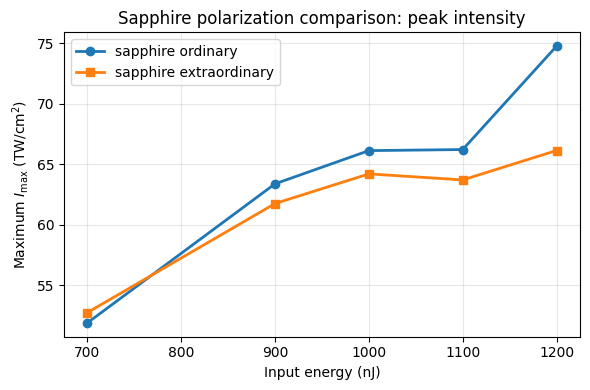

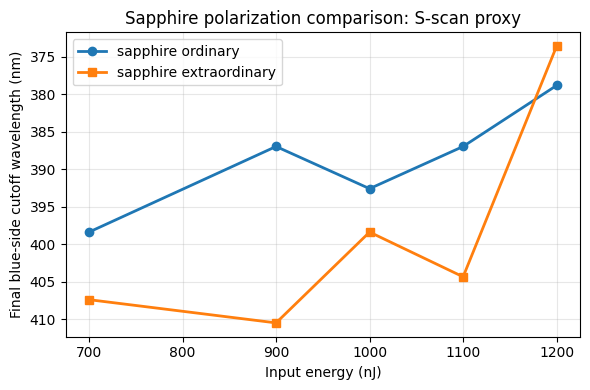

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(
    sapphire_o_df["energy_nJ"],
    sapphire_o_df["Imax_TW_cm2"],
    "o-",
    lw=2,
    label="sapphire ordinary"
)
plt.plot(
    sapphire_e_df["energy_nJ"],
    sapphire_e_df["Imax_TW_cm2"],
    "s-",
    lw=2,
    label="sapphire extraordinary"
)
plt.xlabel("Input energy (nJ)")
plt.ylabel(r"Maximum $I_{\max}$ (TW/cm$^2$)")
plt.title("Sapphire polarization comparison: peak intensity")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(
    sapphire_o_df["energy_nJ"],
    sapphire_o_df["final_cutoff_nm"],
    "o-",
    lw=2,
    label="sapphire ordinary"
)
plt.plot(
    sapphire_e_df["energy_nJ"],
    sapphire_e_df["final_cutoff_nm"],
    "s-",
    lw=2,
    label="sapphire extraordinary"
)
plt.gca().invert_yaxis()
plt.xlabel("Input energy (nJ)")
plt.ylabel("Final blue-side cutoff wavelength (nm)")
plt.title("Sapphire polarization comparison: S-scan proxy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Step A — Create one combined comparison table

combined_df = pd.concat(
    [
        final_scan_df.assign(case="fused_silica"),
        sapphire_o_df.rename(columns={"final_cutoff_nm": "final_cutoff_nm"}).assign(case="sapphire_o"),
        sapphire_e_df.rename(columns={"final_cutoff_nm": "final_cutoff_nm"}).assign(case="sapphire_e"),
    ],
    ignore_index=True
)

display(combined_df)

combined_df.to_csv("A1_5_combined_fused_silica_sapphire_vortex_comparison.csv", index=False)


,energy_nJ,peak_power_MW_est,Imax_TW_cm2,z_Imax_mm,final_cutoff_nm,max_rho_cm3,energy_loss_pct,case,material,beam_type,runtime_s
0,900.0,13.846154,94.480963,9.5,277.509518,1.234931e+18,0.516857,fused_silica,NaN,NaN,NaN
1,1000.0,15.384615,81.186121,9.4,314.736675,4.210714e+17,0.472452,fused_silica,NaN,NaN,NaN
2,1050.0,16.153846,83.436316,11.9,311.107609,6.784122e+17,0.538987,fused_silica,NaN,NaN,NaN
3,1100.0,16.923077,65.664863,10.6,277.509518,3.009422e+17,0.447605,fused_silica,NaN,NaN,NaN
4,1200.0,18.461538,71.890216,11.3,316.583143,4.494099e+17,0.380167,fused_silica,NaN,NaN,NaN
5,700.0,10.769231,51.881026,11.2,398.385578,4.153253e+17,0.436109,sapphire_o,sapphire_o,vortex_m1,982.158287
6,900.0,13.846154,63.376297,9.3,386.958511,4.333353e+17,0.520676,sapphire_o,sapphire_o,vortex_m1,985.310969
7,1000.0,15.384615,66.121537,9.3,392.588910,1.092454e+18,0.663446,sapphire_o,sapphire_o,vortex_m1,983.459419
8,1100.0,16.923077,66.210024,11.2,386.958511,5.421581e+17,0.592553,sapphire_o,sapphire_o,vortex_m1,977.197283
9,1200.0,18.461538,74.755678,10.4,378.809345,2.209365e+18,0.643148,sapphire_o,sapphire_o,vortex_m1,983.770072


In [ ]:
# Step A — Create one combined comparison table - safer version

common_cols = [
    "case",
    "material",
    "beam_type",
    "energy_nJ",
    "peak_power_MW_est",
    "Imax_TW_cm2",
    "z_Imax_mm",
    "final_cutoff_nm",
    "energy_loss_pct",
    "max_rho_cm3"
]

fs_compare = final_scan_df.copy()
fs_compare["case"] = "fused_silica"
fs_compare["material"] = "fused_silica"
fs_compare["beam_type"] = "vortex_m1"

so_compare = sapphire_o_df.copy()
so_compare["case"] = "sapphire_o"

se_compare = sapphire_e_df.copy()
se_compare["case"] = "sapphire_e"

combined_df = pd.concat([fs_compare, so_compare, se_compare], ignore_index=True)

display(combined_df[common_cols])
combined_df[common_cols].to_csv(
    "A1_5_combined_fused_silica_sapphire_vortex_comparison.csv",
    index=False
)


,case,material,beam_type,energy_nJ,peak_power_MW_est,Imax_TW_cm2,z_Imax_mm,final_cutoff_nm,energy_loss_pct,max_rho_cm3
0,fused_silica,fused_silica,vortex_m1,900.0,13.846154,94.480963,9.5,277.509518,0.516857,1.234931e+18
1,fused_silica,fused_silica,vortex_m1,1000.0,15.384615,81.186121,9.4,314.736675,0.472452,4.210714e+17
2,fused_silica,fused_silica,vortex_m1,1050.0,16.153846,83.436316,11.9,311.107609,0.538987,6.784122e+17
3,fused_silica,fused_silica,vortex_m1,1100.0,16.923077,65.664863,10.6,277.509518,0.447605,3.009422e+17
4,fused_silica,fused_silica,vortex_m1,1200.0,18.461538,71.890216,11.3,316.583143,0.380167,4.494099e+17
5,sapphire_o,sapphire_o,vortex_m1,700.0,10.769231,51.881026,11.2,398.385578,0.436109,4.153253e+17
6,sapphire_o,sapphire_o,vortex_m1,900.0,13.846154,63.376297,9.3,386.958511,0.520676,4.333353e+17
7,sapphire_o,sapphire_o,vortex_m1,1000.0,15.384615,66.121537,9.3,392.588910,0.663446,1.092454e+18
8,sapphire_o,sapphire_o,vortex_m1,1100.0,16.923077,66.210024,11.2,386.958511,0.592553,5.421581e+17
9,sapphire_o,sapphire_o,vortex_m1,1200.0,18.461538,74.755678,10.4,378.809345,0.643148,2.209365e+18


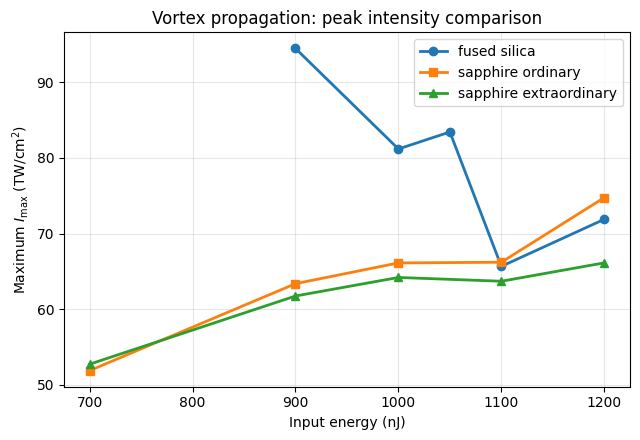

In [ ]:
# Step B — Make final clean plots
# Peak intensity comparison

plt.figure(figsize=(6.5, 4.5))

plt.plot(
    final_scan_df["energy_nJ"],
    final_scan_df["Imax_TW_cm2"],
    "o-",
    lw=2,
    label="fused silica"
)

plt.plot(
    sapphire_o_df["energy_nJ"],
    sapphire_o_df["Imax_TW_cm2"],
    "s-",
    lw=2,
    label="sapphire ordinary"
)

plt.plot(
    sapphire_e_df["energy_nJ"],
    sapphire_e_df["Imax_TW_cm2"],
    "^-",
    lw=2,
    label="sapphire extraordinary"
)

plt.xlabel("Input energy (nJ)")
plt.ylabel(r"Maximum $I_{\max}$ (TW/cm$^2$)")
plt.title("Vortex propagation: peak intensity comparison")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("comparison_peak_intensity.png", dpi=300)
plt.show()


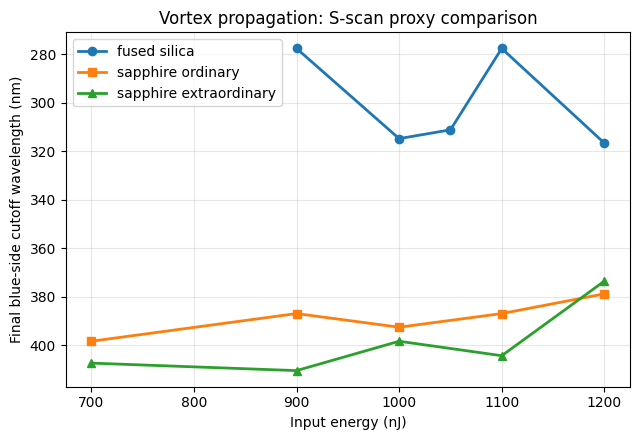

In [ ]:
# S-scan proxy comparison

plt.figure(figsize=(6.5, 4.5))

plt.plot(
    final_scan_df["energy_nJ"],
    final_scan_df["final_cutoff_nm"],
    "o-",
    lw=2,
    label="fused silica"
)

plt.plot(
    sapphire_o_df["energy_nJ"],
    sapphire_o_df["final_cutoff_nm"],
    "s-",
    lw=2,
    label="sapphire ordinary"
)

plt.plot(
    sapphire_e_df["energy_nJ"],
    sapphire_e_df["final_cutoff_nm"],
    "^-",
    lw=2,
    label="sapphire extraordinary"
)

plt.gca().invert_yaxis()
plt.xlabel("Input energy (nJ)")
plt.ylabel("Final blue-side cutoff wavelength (nm)")
plt.title("Vortex propagation: S-scan proxy comparison")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("comparison_s_scan_proxy.png", dpi=300)
plt.show()


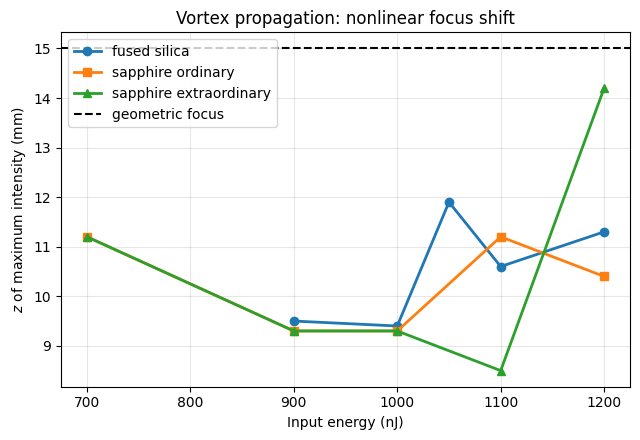

In [ ]:
# Nonlinear focus shift comparison

plt.figure(figsize=(6.5, 4.5))

plt.plot(
    final_scan_df["energy_nJ"],
    final_scan_df["z_Imax_mm"],
    "o-",
    lw=2,
    label="fused silica"
)

plt.plot(
    sapphire_o_df["energy_nJ"],
    sapphire_o_df["z_Imax_mm"],
    "s-",
    lw=2,
    label="sapphire ordinary"
)

plt.plot(
    sapphire_e_df["energy_nJ"],
    sapphire_e_df["z_Imax_mm"],
    "^-",
    lw=2,
    label="sapphire extraordinary"
)

plt.axhline(f_lens * 1e3, color="k", ls="--", label="geometric focus")
plt.xlabel("Input energy (nJ)")
plt.ylabel(r"$z$ of maximum intensity (mm)")
plt.title("Vortex propagation: nonlinear focus shift")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("comparison_focus_shift.png", dpi=300)
plt.show()


In [ ]:
# Step 1 — Save final comparison csv
combined_df.to_csv("FINAL_vortex_material_comparison.csv", index=False)


In [ ]:
# Step 1 — Save final comparison figures

plt.savefig("FINAL_focus_shift_comparison.png", dpi=300, bbox_inches="tight")
plt.savefig("FINAL_peak_intensity_comparison.png", dpi=300, bbox_inches="tight")
plt.savefig("FINAL_s_scan_comparison.png", dpi=300, bbox_inches="tight")


<Figure size 640x480 with 0 Axes>

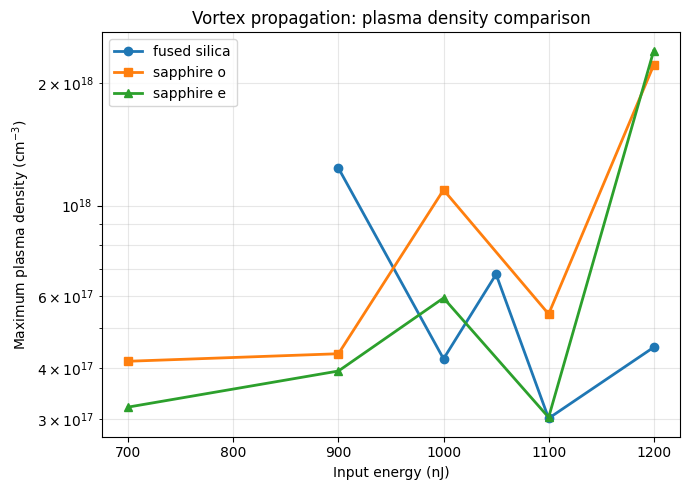

In [ ]:
# Step 2 — Make one plasma-density comparison plot

plt.figure(figsize=(7, 5))

for case_name, marker in [
    ("fused_silica", "o"),
    ("sapphire_o", "s"),
    ("sapphire_e", "^")
]:
    df_case = combined_df[combined_df["case"] == case_name]
    plt.semilogy(
        df_case["energy_nJ"],
        df_case["max_rho_cm3"],
        marker + "-",
        lw=2,
        label=case_name.replace("_", " ")
    )

plt.xlabel("Input energy (nJ)")
plt.ylabel(r"Maximum plasma density (cm$^{-3}$)")
plt.title("Vortex propagation: plasma density comparison")
plt.grid(True, alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.savefig("FINAL_plasma_density_comparison.png", dpi=300)
plt.show()
